# INIT


In [29]:
# ==========================================
# CELLA 1: IMPORT LIBRERIE E SETUP
# ==========================================
import scipy.stats as stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from pyvis.network import Network
import warnings
from itertools import combinations

# Ignoriamo i warning sui dtypes misti per letture veloci
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

# Setup grafica
sns.set_theme(style="whitegrid")
print("✅ Librerie caricate con successo. Ambiente pronto.")

✅ Librerie caricate con successo. Ambiente pronto.


In [30]:
TARGET_GENE = 'KRAS'

COORTI = {
    "kras_pancreas": "../full_try/data_filtered/kras_pancreas",
    "kras_lung": "../full_try/data_filtered/kras_lung",
    "kras_colon": "../full_try/data_filtered/kras_colon",
    "pancreas": "../full_try/data_filtered/pancreas",
    "lung": "../full_try/data_filtered/lung",
    "colon": "../full_try/data_filtered/colon",
}

# MODIFICA: Nuova cartella di output per SV
OUTPUT_BASE_DIR = "./outputs_cna"

COOCC_PARAMS = {
    "kras_pancreas": {"p_val": 0.05, "log2or": 1.0, "min_cooc": 4},
    "kras_lung":     {"p_val": 0.05, "log2or": 1.0, "min_cooc": 5},
    "kras_colon":    {"p_val": 0.05, "log2or": 1.0, "min_cooc": 10},
    "pancreas": {"p_val": 0.05, "log2or": 1.0, "min_cooc": 4},
    "lung":     {"p_val": 0.05, "log2or": 1.0, "min_cooc": 5},
    "colon":    {"p_val": 0.05, "log2or": 1.0, "min_cooc": 10}
}

ME_PARAMS = {
    "kras_pancreas": {"p_val": 0.01, "log2or": -1.0},
    "kras_lung":     {"p_val": 0.01, "log2or": -1.0},
    "kras_colon":    {"p_val": 0.01, "log2or": -1.0},
    "pancreas": {"p_val": 0.01, "log2or": -1.0},
    "lung":     {"p_val": 0.01, "log2or": -1.0},
    "colon":    {"p_val": 0.01, "log2or": -1.0}
}

print("⚙️ Parametri globali configurati per Structural Variants (SV).")

⚙️ Parametri globali configurati per Structural Variants (SV).


# MATRICI


In [31]:
# ==========================================
# CELLA 3: GENERAZIONE MATRICI BINARIE (CNA)
# ==========================================
import os
import pandas as pd

def generate_matrices(path_cohort, cohort_name):
    print(f"\n--- 🧬 PREPARAZIONE DATI CNA: {cohort_name.upper()} ---")
    
    mut_file = f"{path_cohort}/F_data_cna.txt"
    if not os.path.exists(mut_file): 
        print(f"[!] File {mut_file} non trovato. Salto.")
        return
        
    # I file CNA da cBioPortal sono solitamente tab-separated
    df_cna = pd.read_csv(mut_file, sep='\t') 
    
    # TRASFORMAZIONE WIDE -> MATRICE CAMPIONI x GENI
    if 'Hugo_Symbol' in df_cna.columns:
        # Imposta Hugo_Symbol come indice e trasponi la matrice
        df_cna = df_cna.set_index('Hugo_Symbol').T
    else:
        print("[!] Colonna 'Hugo_Symbol' non trovata. Controllare il formato del file.")
        return
        
    # Ora l'indice contiene i Sample_Id
    df_cna.index.name = 'Sample_Id'
    
    # # 🎯 FIX COLON: FILTRO PER STATO MSI
    # if cohort_name == "colon":
    #     clin_file = f"{path_cohort}/F_colon.csv"
    #     if os.path.exists(clin_file):
    #         try:
    #             df_clin = pd.read_csv(clin_file, sep='\t')
    #             if 'MSI Type' not in df_clin.columns:
    #                 df_clin = pd.read_csv(clin_file, sep=',')
    #         except:
    #             df_clin = pd.read_csv(clin_file, sep=',')
                
    #         if 'MSI Type' in df_clin.columns and 'Sample_Id' in df_clin.columns:
    #             stable_samples = df_clin[df_clin['MSI Type'] == 'Stable']['Sample_Id'].tolist()
    #             pazienti_totali = len(df_cna)
                
    #             # Filtra mantenendo solo i pazienti stabili che sono effettivamente nell'indice della matrice CNA
    #             valid_samples = [s for s in stable_samples if s in df_cna.index]
    #             df_cna = df_cna.loc[valid_samples]
                
    #             pazienti_rimasti = len(df_cna)
    #             print(f"[!] APPLICATO FILTRO MSI SUL COLON: Tenuti {pazienti_rimasti} pazienti MSS su {pazienti_totali}.")
    
    # 🎯 ACCORGIMENTO CNA: Filtro biologico per eventi ad alto impatto
    # Consideriamo significativi solo Amplificazioni (2 / 2.0) e Delezioni profonde (-2 / -2.0)
    # Questo crea direttamente una matrice di booleani e la converte in 0 e 1
    binary_matrix = ((df_cna == 2) | (df_cna == 2.0) | (df_cna == -2) | (df_cna == -2.0)).astype(int)
    
    # ==========================================
    # 📊 NUOVO BLOCCO: CALCOLO STATISTICHE
    # ==========================================
    num_samples, num_genes = binary_matrix.shape
    total_events = binary_matrix.sum().sum()
    
    # Somma per riga: quanti geni alterati (CNA) ha in media un paziente?
    events_per_sample = binary_matrix.sum(axis=1)
    
    # Somma per colonna: in quanti pazienti è alterato un singolo gene?
    events_per_gene = binary_matrix.sum(axis=0)
    
    print("\n📊 --- STATISTICHE MATRICE CNA ---")
    print(f"  • Dimensioni Rete: {num_samples} Campioni x {num_genes} Geni")
    print(f"  • Totale eventi CNA significativi: {total_events} (Amp +2 / Del -2)")
    print(f"  • Densità matrice (Sparsity): {(total_events / (num_samples * num_genes)) * 100:.2f}% delle celle ha un'alterazione")
    
    print("\n  📉 CNA Burden per Paziente (Geni alterati per singolo campione):")
    print(f"    - Media:   {events_per_sample.mean():.2f}")
    print(f"    - Mediana: {events_per_sample.median():.2f}")
    print(f"    - Massimo: {events_per_sample.max()}")
    print(f"    - Minimo:  {events_per_sample.min()}")
    
    print("\n  📈 Frequenza CNA per Gene (Pazienti alterati per singolo gene):")
    print(f"    - Media:   {events_per_gene.mean():.2f}")
    print(f"    - Mediana: {events_per_gene.median():.2f}")
    print(f"    - Massimo: {events_per_gene.max()}")
    
    # Trova i 5 geni più frequentemente alterati tramite CNA
    top_genes = events_per_gene.sort_values(ascending=False).head(5)
    print("\n  🔥 Top 5 Geni con maggior prevalenza CNA:")
    for g, count in top_genes.items():
        print(f"    - {g}: {count} alterazioni ({(count/num_samples)*100:.1f}% della coorte)")
    print("----------------------------------------------------\n")
    # ==========================================
    
    # Creazione della matrice di co-occorrenza (Geni x Geni)
    co_occ_matrix = binary_matrix.T.dot(binary_matrix)
    
    # Salvataggio
    out_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/matrices"
    os.makedirs(out_dir, exist_ok=True)
    
    binary_matrix.to_csv(f"{out_dir}/M_binary_{cohort_name}.tsv", sep='\t')
    co_occ_matrix.to_csv(f"{out_dir}/M_cooccurrence_{cohort_name}.tsv", sep='\t')
    print(f"✅ Matrici CNA salvate in: {out_dir}")

# Esecuzione del ciclo (assicurati che COORTI e OUTPUT_BASE_DIR siano definiti)
for name, path in COORTI.items():
    generate_matrices(path, name)


--- 🧬 PREPARAZIONE DATI CNA: KRAS_PANCREAS ---

📊 --- STATISTICHE MATRICE CNA ---
  • Dimensioni Rete: 812 Campioni x 702 Geni
  • Totale eventi CNA significativi: 1855 (Amp +2 / Del -2)
  • Densità matrice (Sparsity): 0.33% delle celle ha un'alterazione

  📉 CNA Burden per Paziente (Geni alterati per singolo campione):
    - Media:   2.28
    - Mediana: 1.00
    - Massimo: 26
    - Minimo:  0

  📈 Frequenza CNA per Gene (Pazienti alterati per singolo gene):
    - Media:   2.64
    - Mediana: 0.00
    - Massimo: 175

  🔥 Top 5 Geni con maggior prevalenza CNA:
    - CDKN2A: 175 alterazioni (21.6% della coorte)
    - CDKN2Ap16INK4A: 173 alterazioni (21.3% della coorte)
    - CDKN2Ap14ARF: 171 alterazioni (21.1% della coorte)
    - CDKN2B: 165 alterazioni (20.3% della coorte)
    - MYC: 55 alterazioni (6.8% della coorte)
----------------------------------------------------

✅ Matrici CNA salvate in: ./outputs_cna/kras_pancreas/matrices

--- 🧬 PREPARAZIONE DATI CNA: KRAS_LUNG ---

📊 --- S

# ANALISI STATISTICA


In [32]:
# ==========================================
# CELLA 4: ANALISI STATISTICA (FISHER EXACT + FDR)
# ==========================================

def calculate_statistics(cohort_name):
    print(f"\n--- 🧮 CALCOLO STATISTICHE: {cohort_name.upper()} ---")
    
    bin_file = f"{OUTPUT_BASE_DIR}/{cohort_name}/matrices/M_binary_{cohort_name}.tsv"
    if not os.path.exists(bin_file):
        return
        
    df_bin = pd.read_csv(bin_file, sep='\t', index_col=0).fillna(0)
    genes = df_bin.columns.tolist()
    n_total = len(df_bin)
    gene_counts = df_bin.sum(axis=0).astype(int)
    
    out_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/stats"
    os.makedirs(out_dir, exist_ok=True)
    
    # ---------------------------------------------------------
    # 1. CO-OCCORRENZA FULL PATH (Tutti vs Tutti)
    # ---------------------------------------------------------
    full_results = []
    print(f"[*] Calcolo Co-occorrenza globale...")
    for g1, g2 in combinations(genes, 2):
        a = ((df_bin[g1] == 1) & (df_bin[g2] == 1)).sum()
        if a < 2: continue # Filtro rumore
            
        b = gene_counts[g1] - a
        c = gene_counts[g2] - a
        d = n_total - (a + b + c)

        odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative='greater')
        log2or = np.log2(odds_ratio) if odds_ratio > 0 else -10.0

        full_results.append({
            'Gene_A': g1, 'Gene_B': g2, 'Co_Occurrence_Count': a,
            'P_Value': p_value, 'Log2OR': log2or
        })

    if full_results:
        df_full = pd.DataFrame(full_results)
        df_full['P_Adj'] = multipletests(df_full['P_Value'], method='fdr_bh')[1]
        df_full['Log2OR'] = df_full['Log2OR'].replace([np.inf, -np.inf], [10.0, -10.0])
        df_full.to_csv(f"{out_dir}/Full_Cooccurrence_Stats_{cohort_name}.tsv", sep='\t', index=False)
        print(f"✅ Statistiche di Co-occorrenza salvate.")

    # ---------------------------------------------------------
    # 2. MUTUA ESCLUSIVITÀ (Target vs Tutti)
    # ---------------------------------------------------------
    if TARGET_GENE not in genes:
        print(f"[!] {TARGET_GENE} assente. Salto Mutua Esclusività.")
        return
        
    me_results = []
    print(f"[*] Calcolo Mutua Esclusività per {TARGET_GENE}...")
    target_mut = df_bin[TARGET_GENE]
    
    for gene in genes:
        if gene == TARGET_GENE: continue
        gene_mut = df_bin[gene]
        
        both_mut = ((target_mut == 1) & (gene_mut == 1)).sum()
        only_target = ((target_mut == 1) & (gene_mut == 0)).sum()
        only_gene = ((target_mut == 0) & (gene_mut == 1)).sum()
        neither_mut = ((target_mut == 0) & (gene_mut == 0)).sum()
        
        oddsratio, p_value = fisher_exact([[both_mut, only_target], [only_gene, neither_mut]], alternative='less')
        
        if oddsratio == 0: log2or = -10.0
        elif oddsratio == np.inf: log2or = 10.0
        else: log2or = np.log2(oddsratio)
            
        me_results.append({
            'Gene_A': TARGET_GENE, 'Gene_B': gene, 'Co_Occurrence_Count': both_mut,
            'Only_KRAS': only_target, 'Only_Gene_B': only_gene, 'Neither': neither_mut,
            'P_Value': p_value, 'Log2OR': log2or
        })
        
    if me_results:
        df_me = pd.DataFrame(me_results)
        df_me['P_Adj'] = multipletests(df_me['P_Value'], method='fdr_bh')[1]
        df_me = df_me.sort_values('P_Value')
        df_me.to_csv(f"{out_dir}/Mutual_Exclusivity_Stats_{cohort_name}.tsv", sep='\t', index=False)
        print(f"✅ Statistiche di Mutua Esclusività salvate.")

for name in COORTI.keys():
    calculate_statistics(name)


--- 🧮 CALCOLO STATISTICHE: KRAS_PANCREAS ---
[*] Calcolo Co-occorrenza globale...
✅ Statistiche di Co-occorrenza salvate.
[*] Calcolo Mutua Esclusività per KRAS...
✅ Statistiche di Mutua Esclusività salvate.

--- 🧮 CALCOLO STATISTICHE: KRAS_LUNG ---
[*] Calcolo Co-occorrenza globale...
✅ Statistiche di Co-occorrenza salvate.
[*] Calcolo Mutua Esclusività per KRAS...
✅ Statistiche di Mutua Esclusività salvate.

--- 🧮 CALCOLO STATISTICHE: KRAS_COLON ---
[*] Calcolo Co-occorrenza globale...
✅ Statistiche di Co-occorrenza salvate.
[*] Calcolo Mutua Esclusività per KRAS...
✅ Statistiche di Mutua Esclusività salvate.

--- 🧮 CALCOLO STATISTICHE: PANCREAS ---
[*] Calcolo Co-occorrenza globale...
✅ Statistiche di Co-occorrenza salvate.
[*] Calcolo Mutua Esclusività per KRAS...
✅ Statistiche di Mutua Esclusività salvate.

--- 🧮 CALCOLO STATISTICHE: LUNG ---
[*] Calcolo Co-occorrenza globale...
✅ Statistiche di Co-occorrenza salvate.
[*] Calcolo Mutua Esclusività per KRAS...
✅ Statistiche di Mut


--- 🌋 GENERAZIONE PLOTS (P-Adj): KRAS_PANCREAS ---


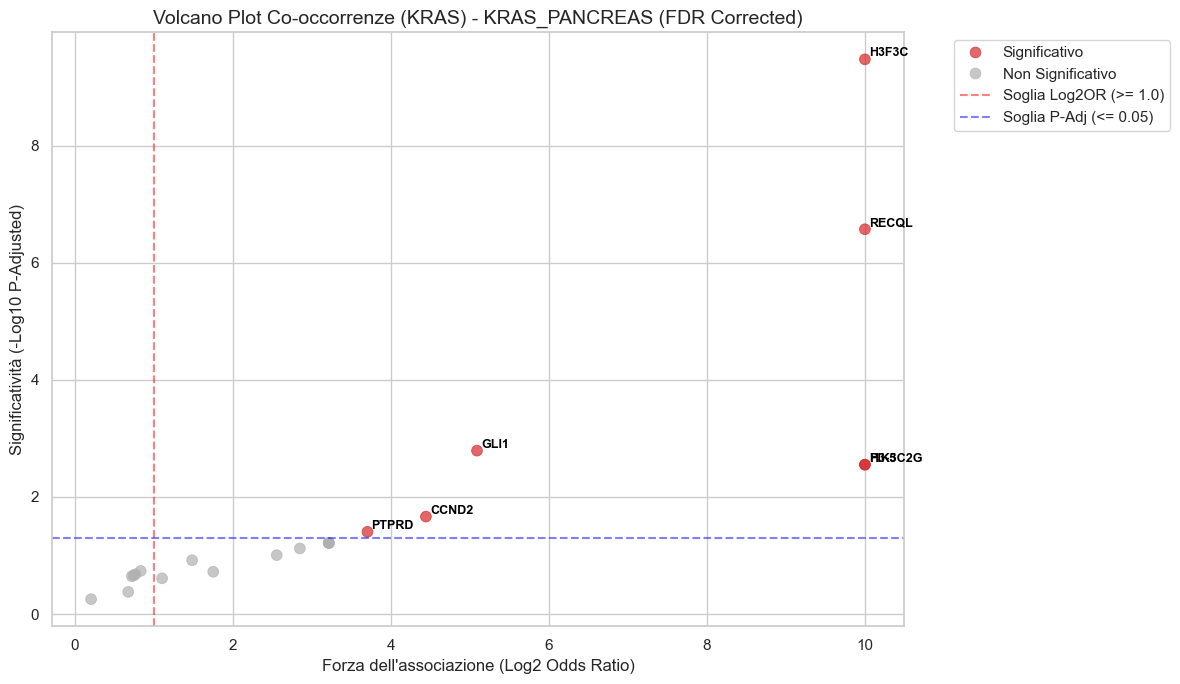

✅ Volcano Plot Co-occorrenze (P-Adj) salvato e visualizzato.



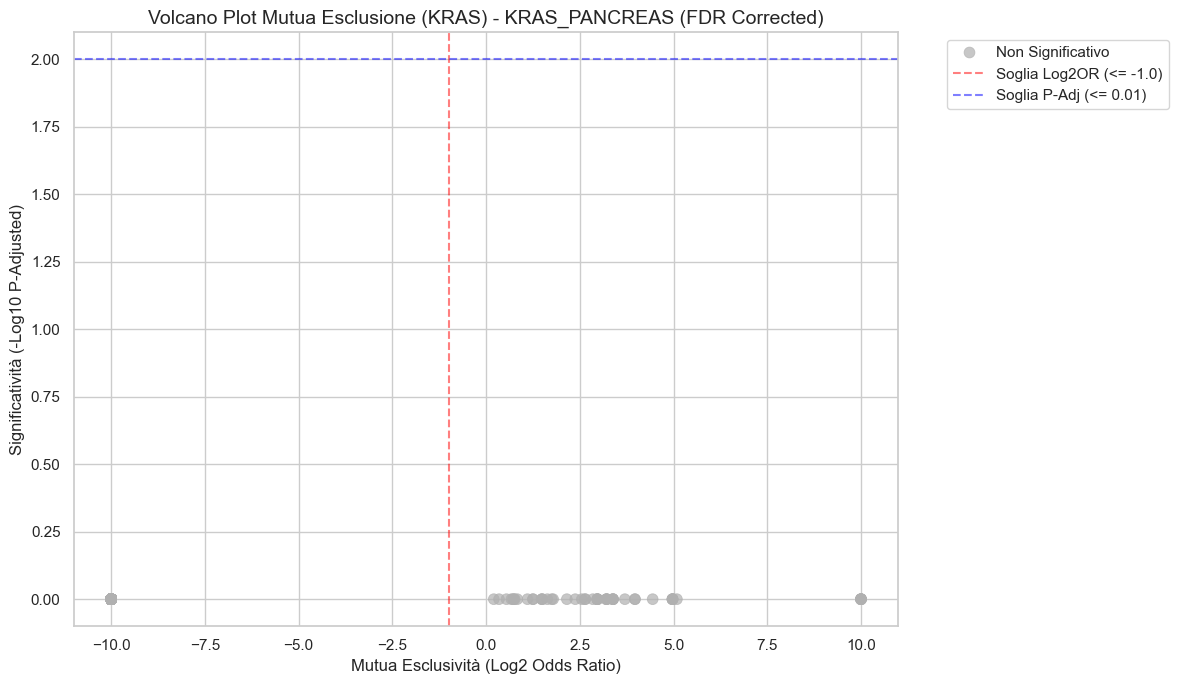

✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.


--- 🌋 GENERAZIONE PLOTS (P-Adj): KRAS_LUNG ---


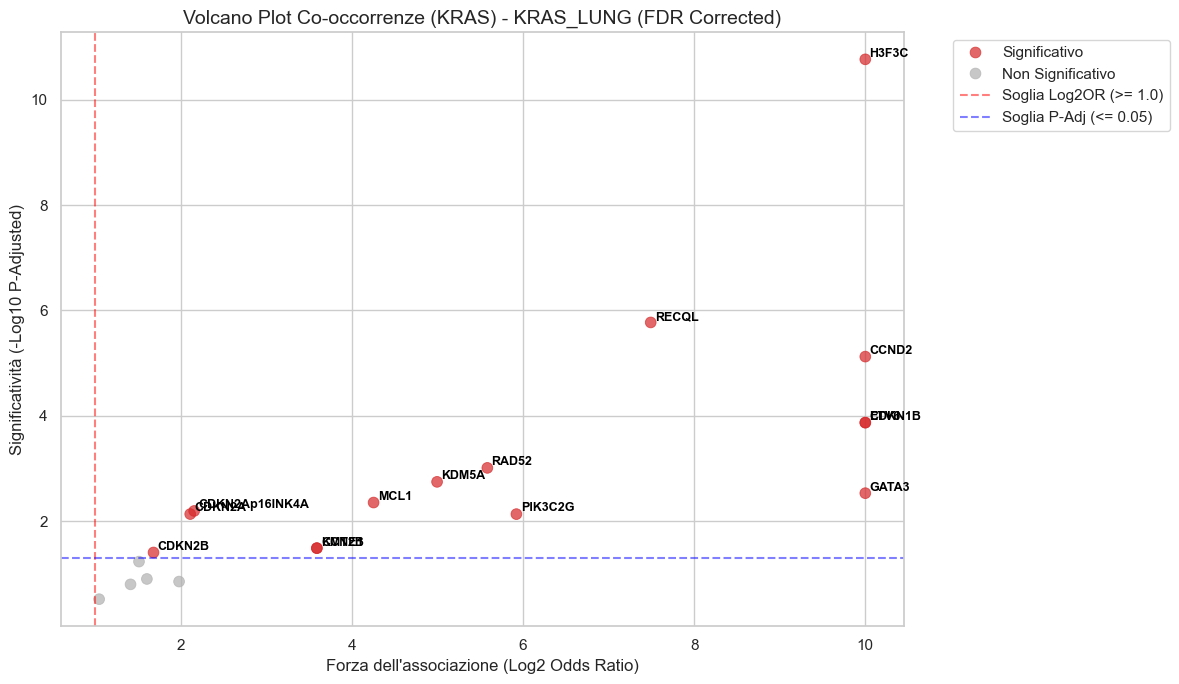

✅ Volcano Plot Co-occorrenze (P-Adj) salvato e visualizzato.



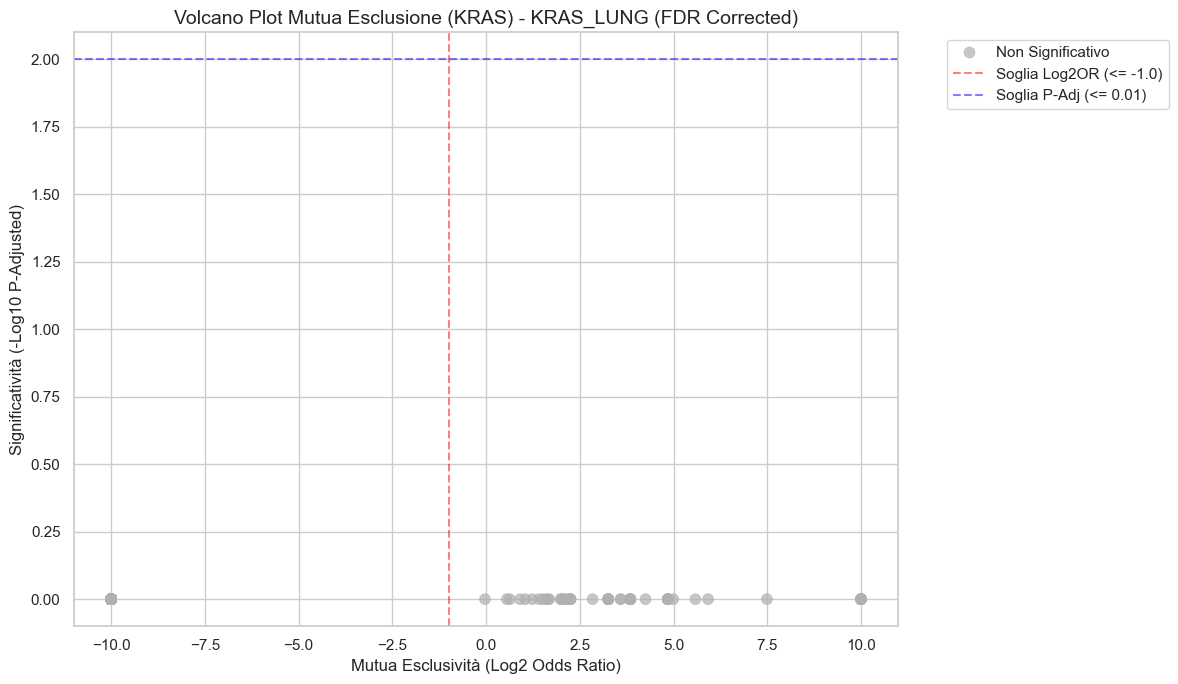

✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.


--- 🌋 GENERAZIONE PLOTS (P-Adj): KRAS_COLON ---


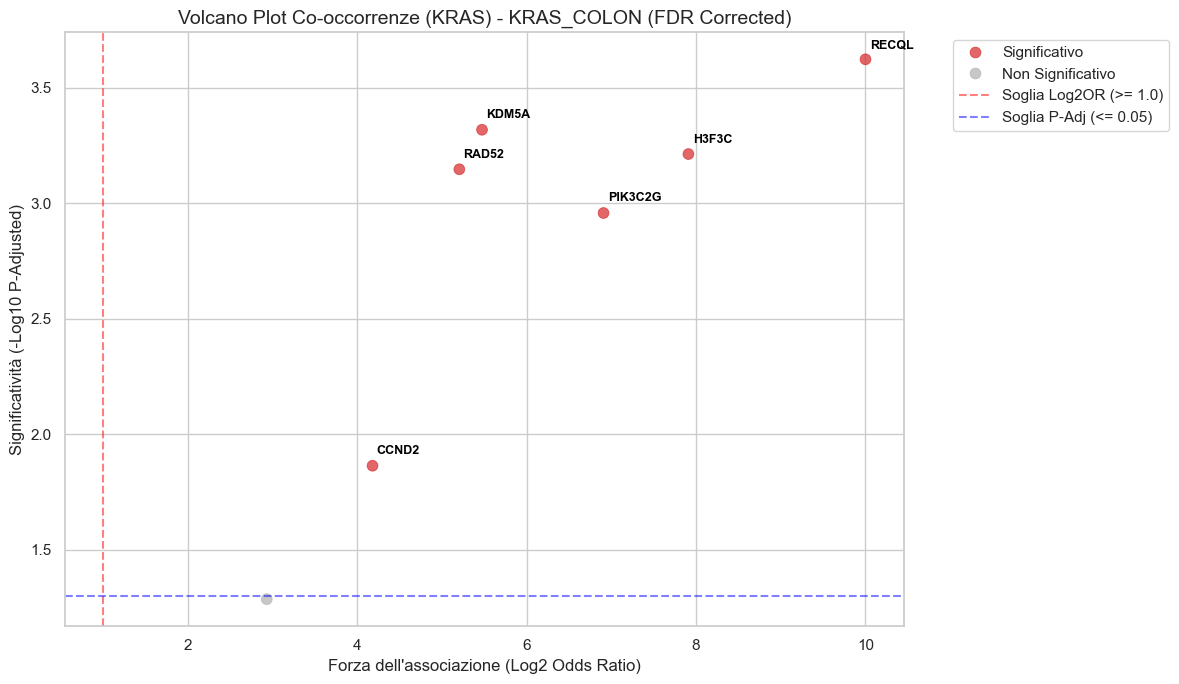

✅ Volcano Plot Co-occorrenze (P-Adj) salvato e visualizzato.



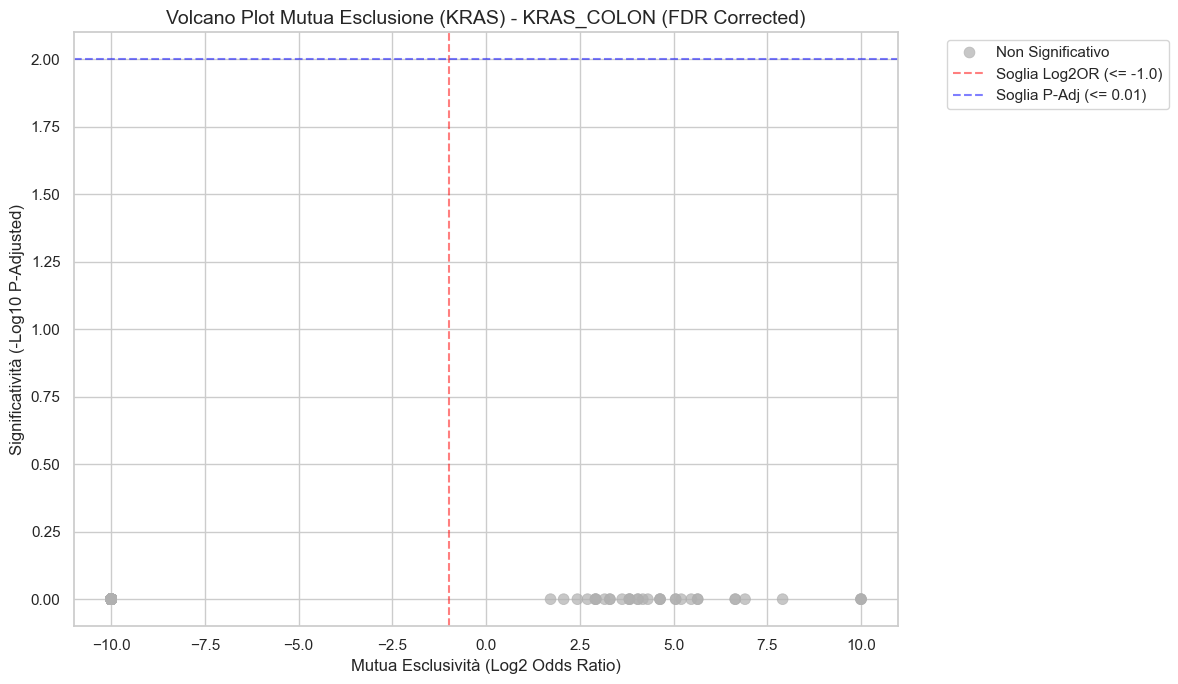

✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.


--- 🌋 GENERAZIONE PLOTS (P-Adj): PANCREAS ---


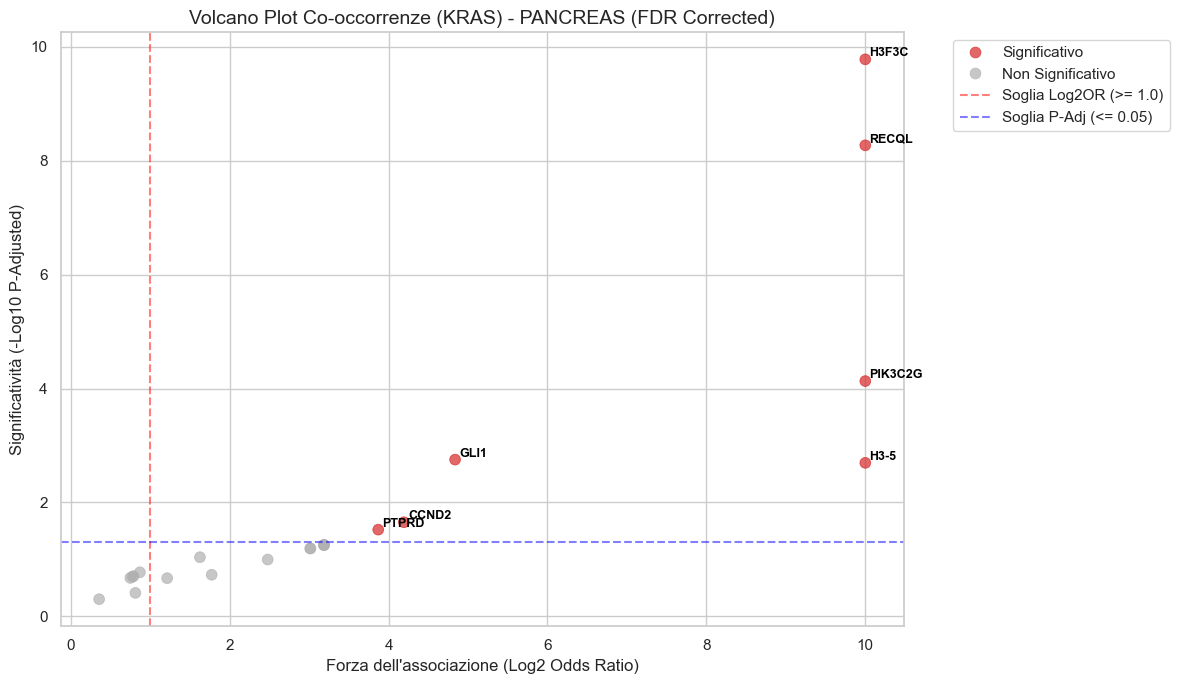

✅ Volcano Plot Co-occorrenze (P-Adj) salvato e visualizzato.



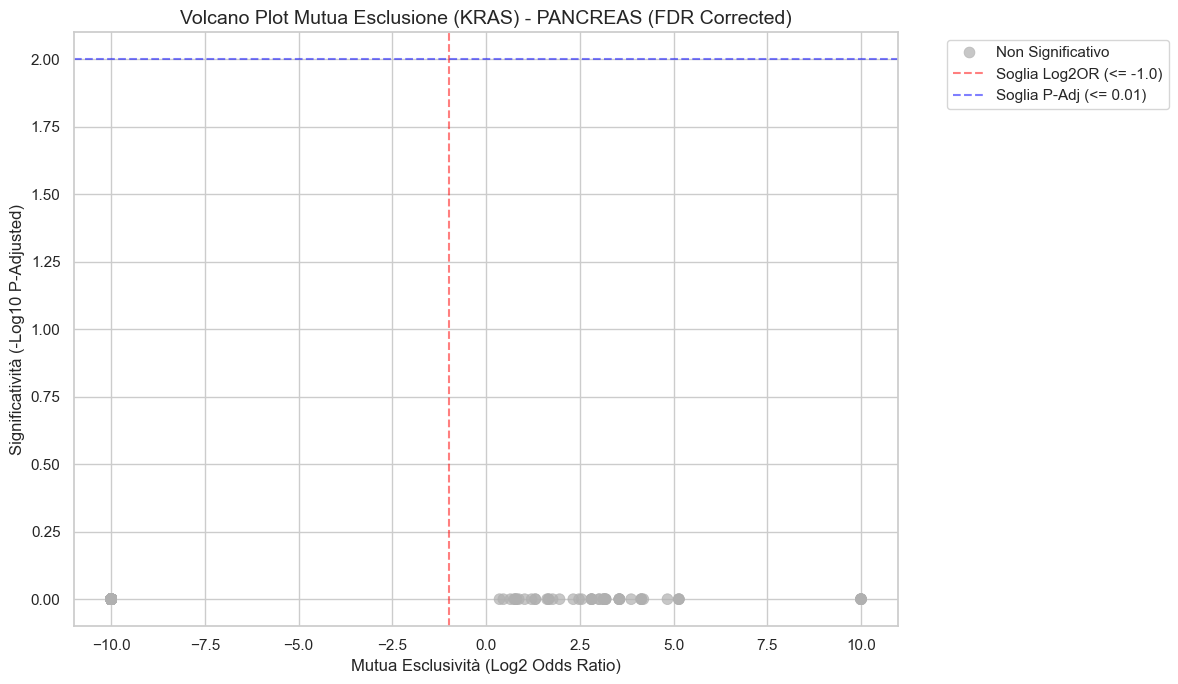

✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.


--- 🌋 GENERAZIONE PLOTS (P-Adj): LUNG ---


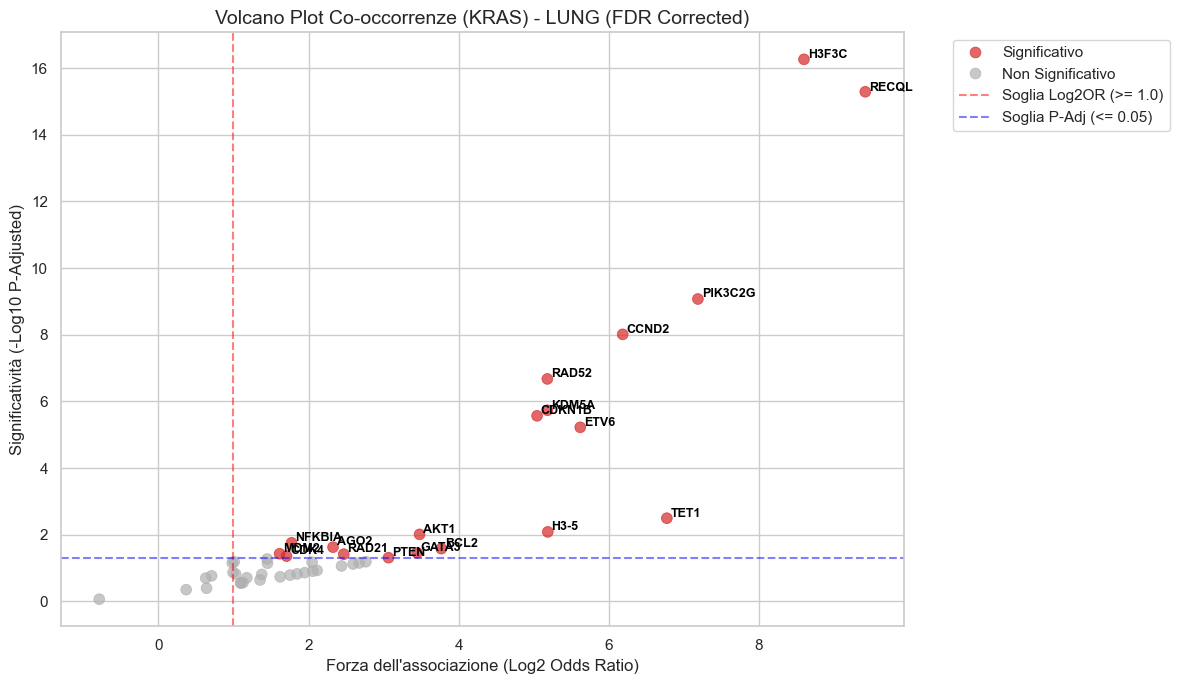

✅ Volcano Plot Co-occorrenze (P-Adj) salvato e visualizzato.



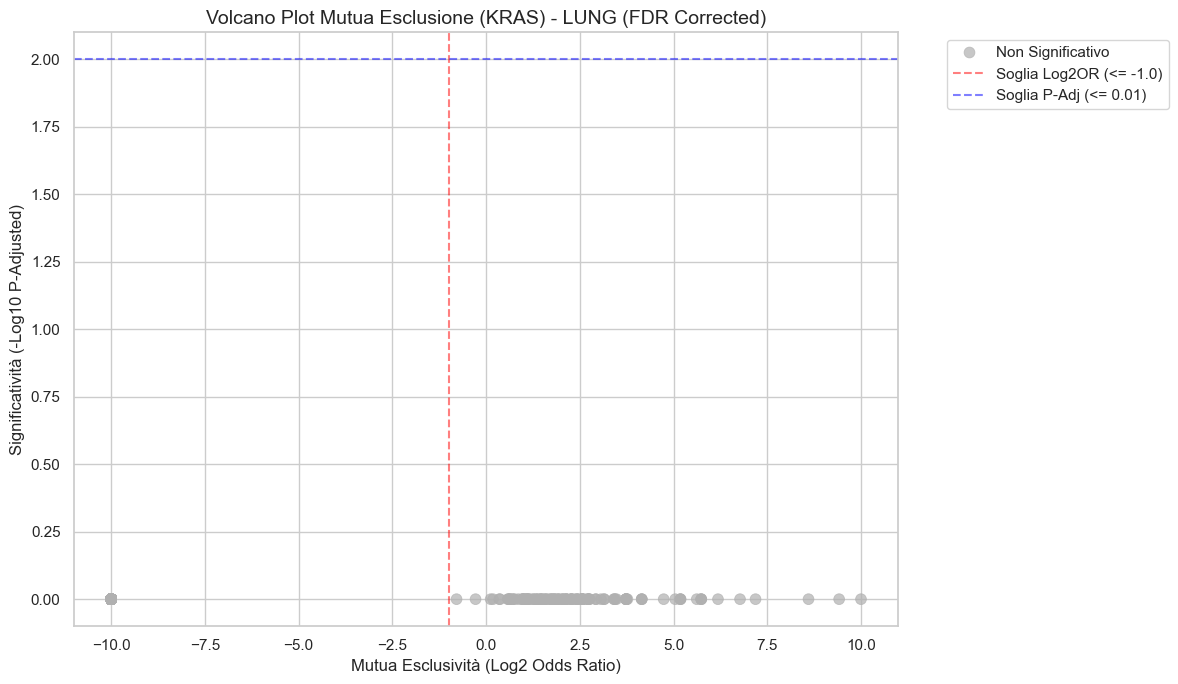

✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.


--- 🌋 GENERAZIONE PLOTS (P-Adj): COLON ---


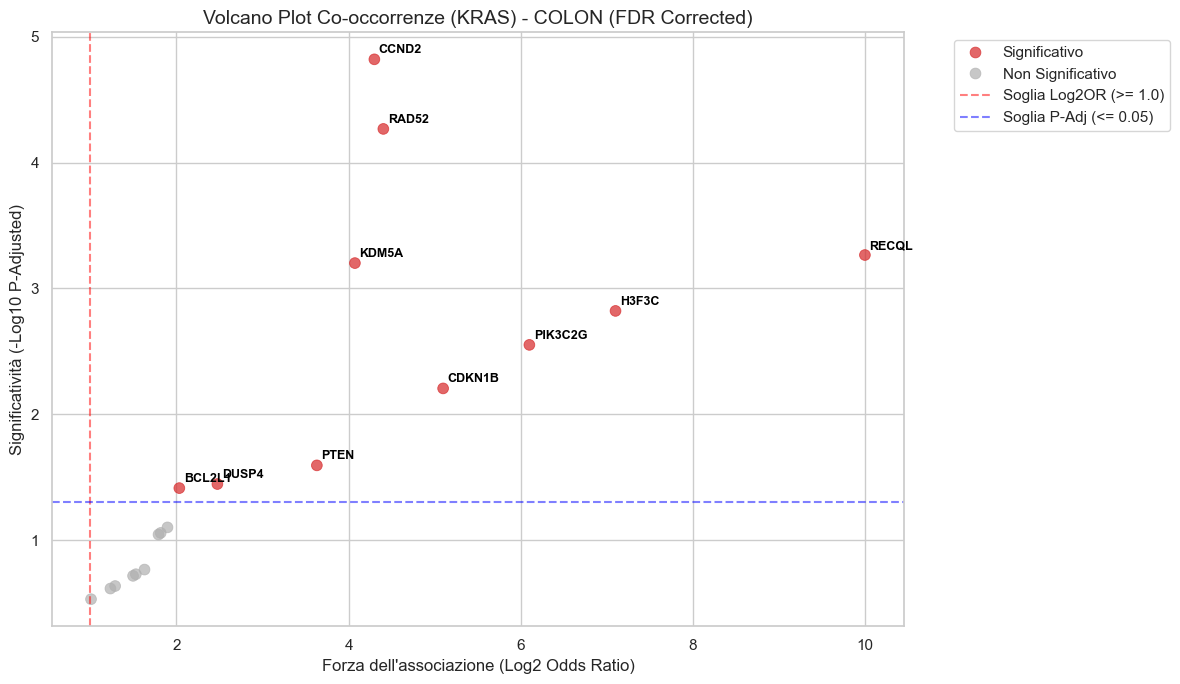

✅ Volcano Plot Co-occorrenze (P-Adj) salvato e visualizzato.



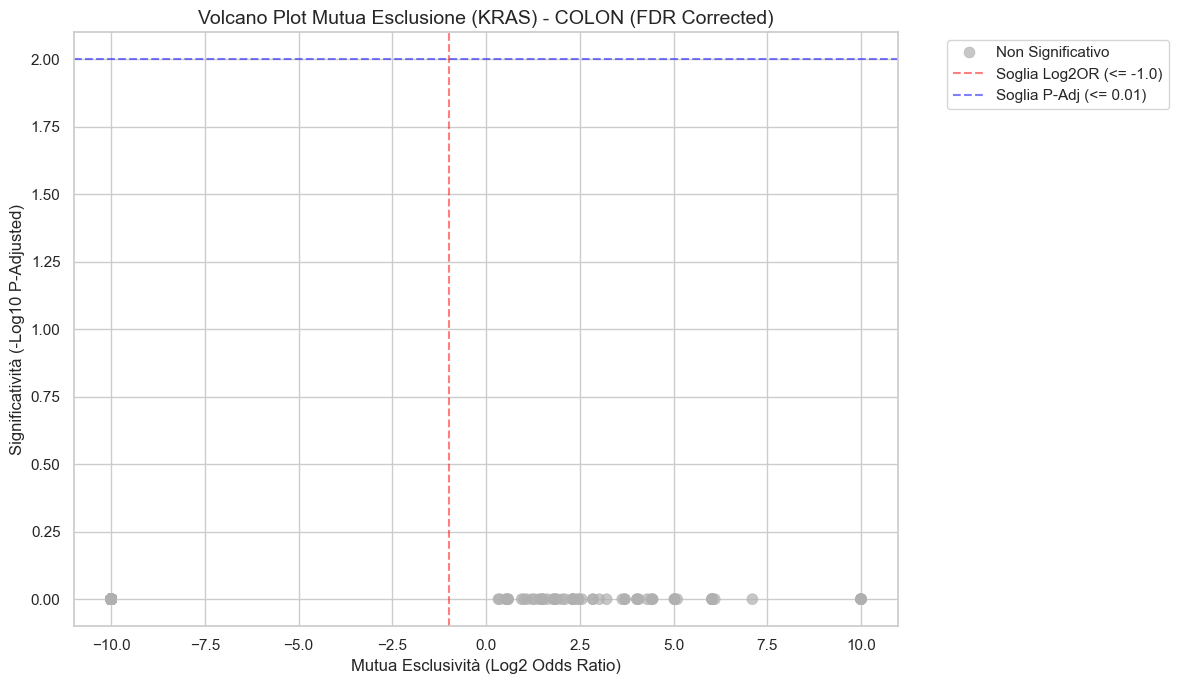

✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.



In [33]:
# ==========================================
# CELLA 5: VOLCANO PLOTS CON P-ADJUSTED (FDR)
# ==========================================

def plot_volcanos(cohort_name):
    print(f"\n--- 🌋 GENERAZIONE PLOTS (P-Adj): {cohort_name.upper()} ---")
    out_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/plots"
    os.makedirs(out_dir, exist_ok=True)
    
    stats_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/stats"
    
    # ---------------------------------------------------------
    # 1. Plot Co-occorrenze
    # ---------------------------------------------------------
    full_file = f"{stats_dir}/Full_Cooccurrence_Stats_{cohort_name}.tsv"
    if os.path.exists(full_file):
        df = pd.read_csv(full_file, sep='\t')
        
        # Estraiamo solo le coppie con KRAS
        df_kras = df[(df['Gene_A'] == TARGET_GENE) | (df['Gene_B'] == TARGET_GENE)].copy()
        
        if not df_kras.empty:
            p_thresh = COOCC_PARAMS[cohort_name]['p_val']
            log_thresh = COOCC_PARAMS[cohort_name]['log2or']
            
            # Identifichiamo il gene partner
            df_kras['Partner'] = df_kras.apply(lambda row: row['Gene_B'] if row['Gene_A'] == TARGET_GENE else row['Gene_A'], axis=1)
            
            # MODIFICA: Calcolo su P_Adj
            df_kras['neg_log10_p_adj'] = -np.log10(df_kras['P_Adj'] + 1e-300)
            cond_sig = (df_kras['Log2OR'] >= log_thresh) & (df_kras['P_Adj'] <= p_thresh)
            df_kras['Stato'] = np.where(cond_sig, 'Significativo', 'Non Significativo')
            
            plt.figure(figsize=(12, 7))
            sns.scatterplot(data=df_kras, x='Log2OR', y='neg_log10_p_adj', hue='Stato', 
                            palette={'Significativo': '#d62728', 'Non Significativo': '#b0b0b0'},
                            alpha=0.7, s=60, edgecolor=None)
            
            # Linee di soglia
            plt.axvline(x=log_thresh, color='red', linestyle='--', alpha=0.5, label=f'Soglia Log2OR (>= {log_thresh})')
            plt.axhline(y=-np.log10(p_thresh), color='blue', linestyle='--', alpha=0.5, label=f'Soglia P-Adj (<= {p_thresh})')
            
            # Aggiunta etichette per i geni significativi
            for _, row in df_kras[cond_sig].iterrows():
                plt.text(row['Log2OR'] + 0.05, row['neg_log10_p_adj'] + 0.05, row['Partner'], 
                         fontsize=9, weight='bold', color='black')
            
            plt.title(f'Volcano Plot Co-occorrenze ({TARGET_GENE}) - {cohort_name.upper()} (FDR Corrected)', fontsize=14)
            plt.xlabel('Forza dell\'associazione (Log2 Odds Ratio)')
            plt.ylabel('Significatività (-Log10 P-Adjusted)')
            
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            
            # Sovrascrive il file precedente
            plt.savefig(f"{out_dir}/Volcano_Cooccurrence_{cohort_name}.png", dpi=150)
            plt.show() 
            print("✅ Volcano Plot Co-occorrenze (P-Adj) salvato e visualizzato.\n")

    # ---------------------------------------------------------
    # 2. Plot Mutua Esclusione
    # ---------------------------------------------------------
    me_file = f"{stats_dir}/Mutual_Exclusivity_Stats_{cohort_name}.tsv"
    if os.path.exists(me_file):
        df_me = pd.read_csv(me_file, sep='\t')
        p_thresh_me = ME_PARAMS[cohort_name]['p_val']
        log_thresh_me = ME_PARAMS[cohort_name]['log2or']
        
        # MODIFICA: Calcolo su P_Adj
        df_me['neg_log10_p_adj'] = -np.log10(df_me['P_Adj'] + 1e-300)
        cond_sig_me = (df_me['Log2OR'] <= log_thresh_me) & (df_me['P_Adj'] <= p_thresh_me)
        df_me['Stato'] = np.where(cond_sig_me, 'Significativo', 'Non Significativo')
        
        plt.figure(figsize=(12, 7))
        sns.scatterplot(data=df_me, x='Log2OR', y='neg_log10_p_adj', hue='Stato',
                        palette={'Significativo': '#1f77b4', 'Non Significativo': '#b0b0b0'},
                        alpha=0.7, s=60, edgecolor=None)
                        
        plt.axvline(x=log_thresh_me, color='red', linestyle='--', alpha=0.5, label=f'Soglia Log2OR (<= {log_thresh_me})')
        plt.axhline(y=-np.log10(p_thresh_me), color='blue', linestyle='--', alpha=0.5, label=f'Soglia P-Adj (<= {p_thresh_me})')
        
        # Aggiunta etichette per i geni significativi
        for _, row in df_me[cond_sig_me].iterrows():
            plt.text(row['Log2OR'] - 0.05, row['neg_log10_p_adj'] + 0.05, row['Gene_B'], 
                     fontsize=9, weight='bold', color='black', horizontalalignment='right')
        
        plt.title(f'Volcano Plot Mutua Esclusione ({TARGET_GENE}) - {cohort_name.upper()} (FDR Corrected)', fontsize=14)
        plt.xlabel('Mutua Esclusività (Log2 Odds Ratio)')
        plt.ylabel('Significatività (-Log10 P-Adjusted)')
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        
        # Sovrascrive il file precedente
        plt.savefig(f"{out_dir}/Volcano_Mutual_Exclusivity_{cohort_name}.png", dpi=150)
        plt.show() 
        print("✅ Volcano Plot Mutua Esclusione (P-Adj) salvato e visualizzato.\n")

for name in COORTI.keys():
    plot_volcanos(name)

# RETI FULL E FILTERED (1-HOP)



--- 🌐 GENERAZIONE RETI 2D: KRAS_PANCREAS ---


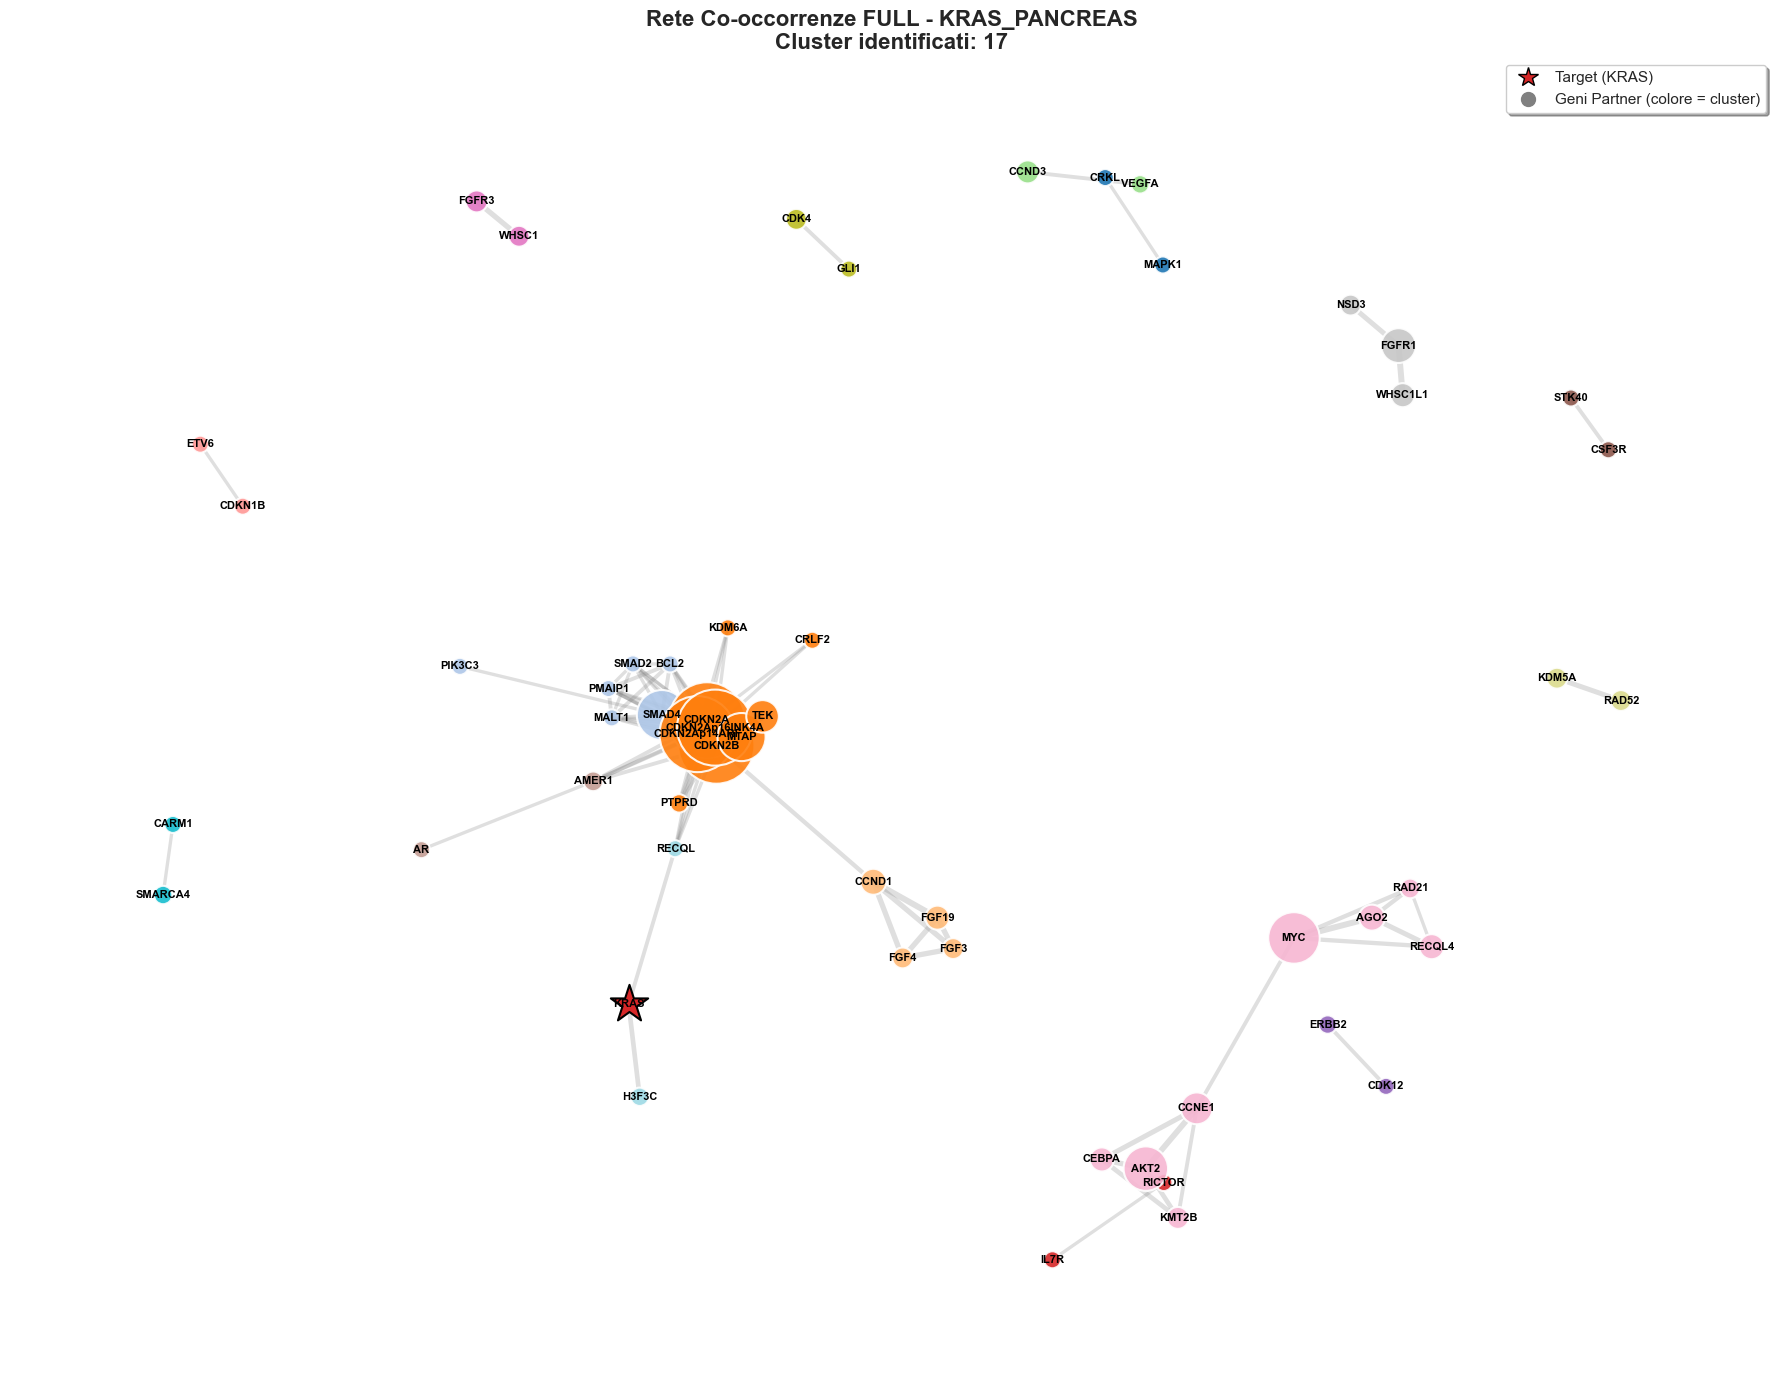

✅ Rete FULL per KRAS_PANCREAS salvata. Nodi: 55, Archi: 99


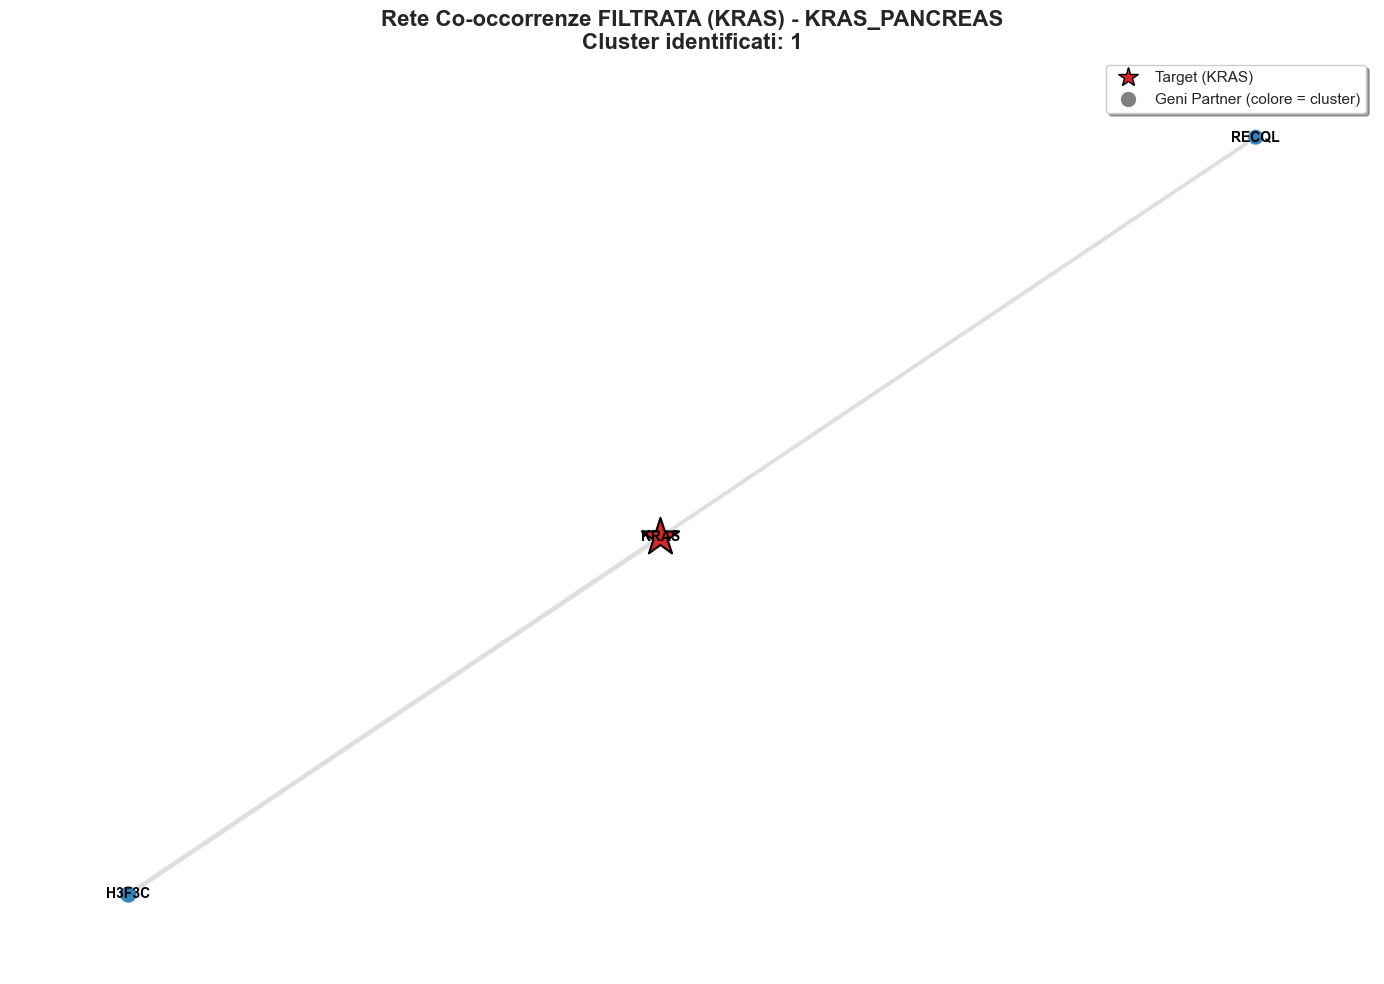

✅ Rete FILTRATA (KRAS) per KRAS_PANCREAS salvata. Nodi: 3, Archi: 2

--- 🌐 GENERAZIONE RETI 2D: KRAS_LUNG ---


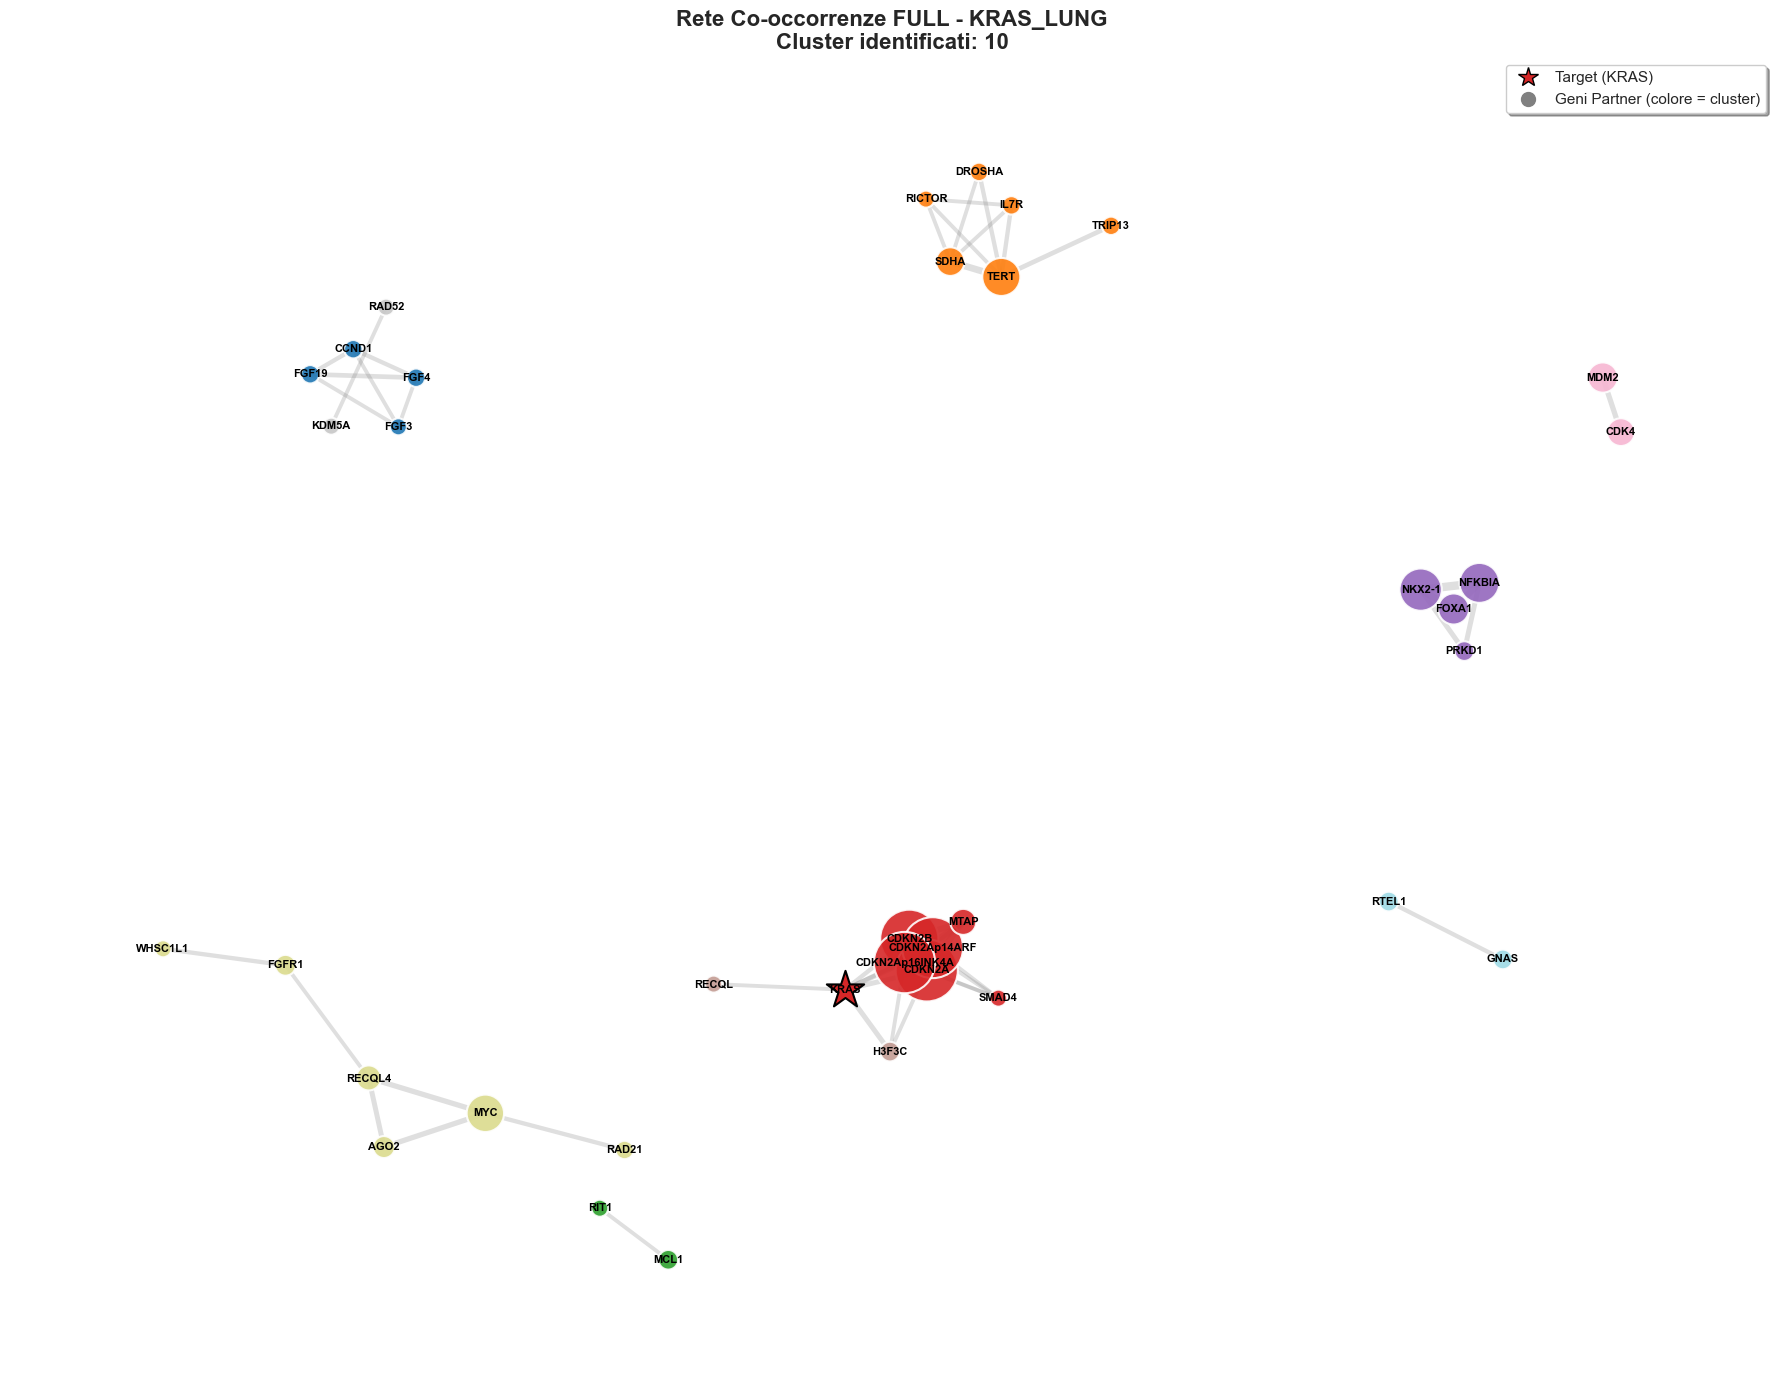

✅ Rete FULL per KRAS_LUNG salvata. Nodi: 37, Archi: 52


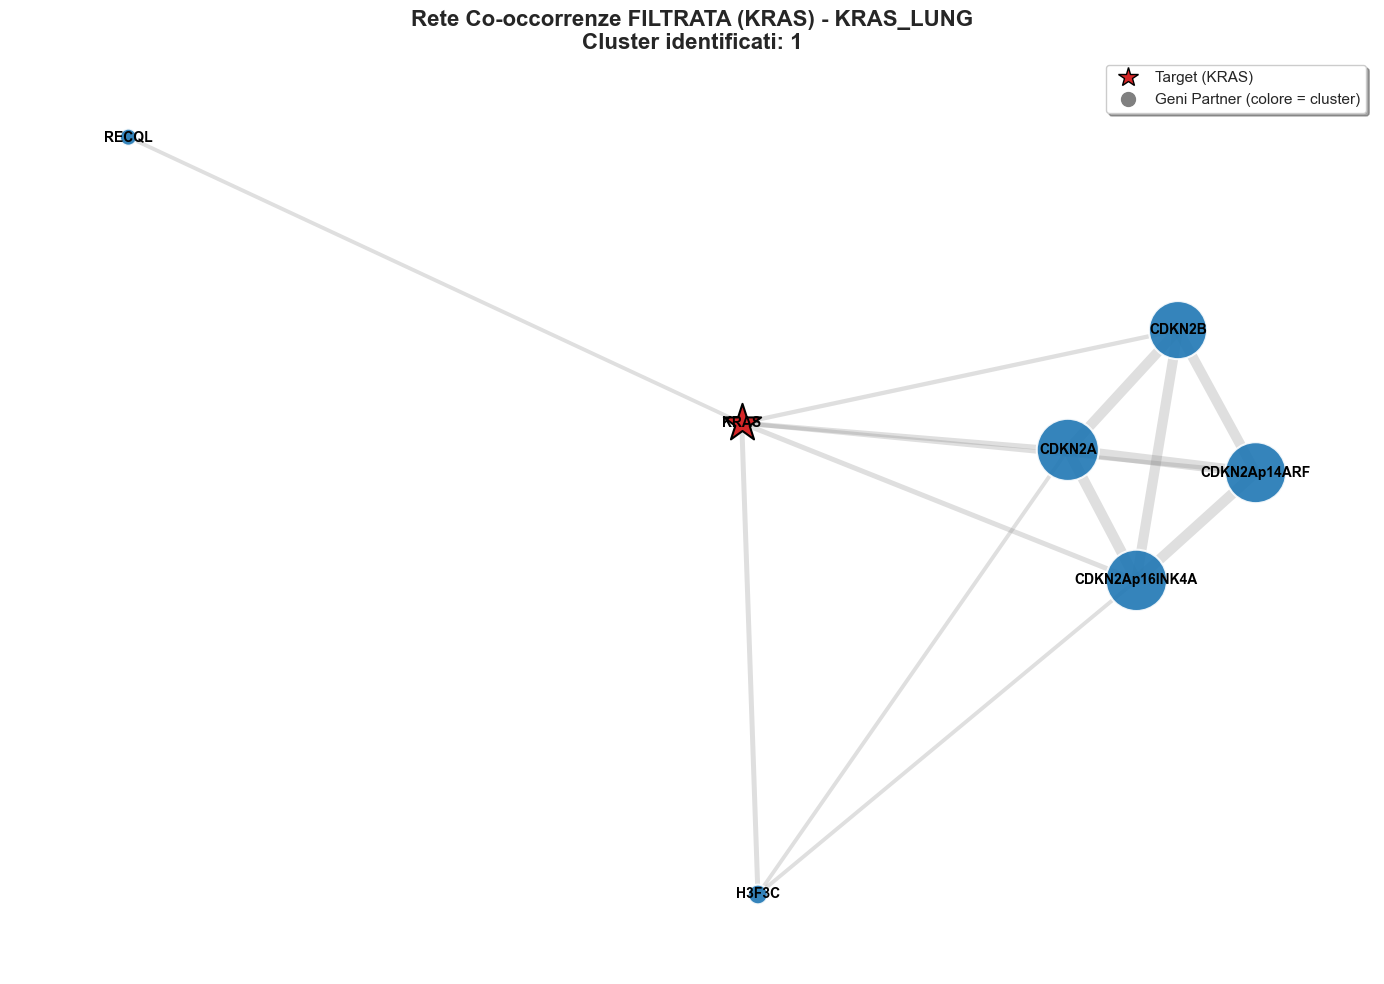

✅ Rete FILTRATA (KRAS) per KRAS_LUNG salvata. Nodi: 7, Archi: 14

--- 🌐 GENERAZIONE RETI 2D: KRAS_COLON ---


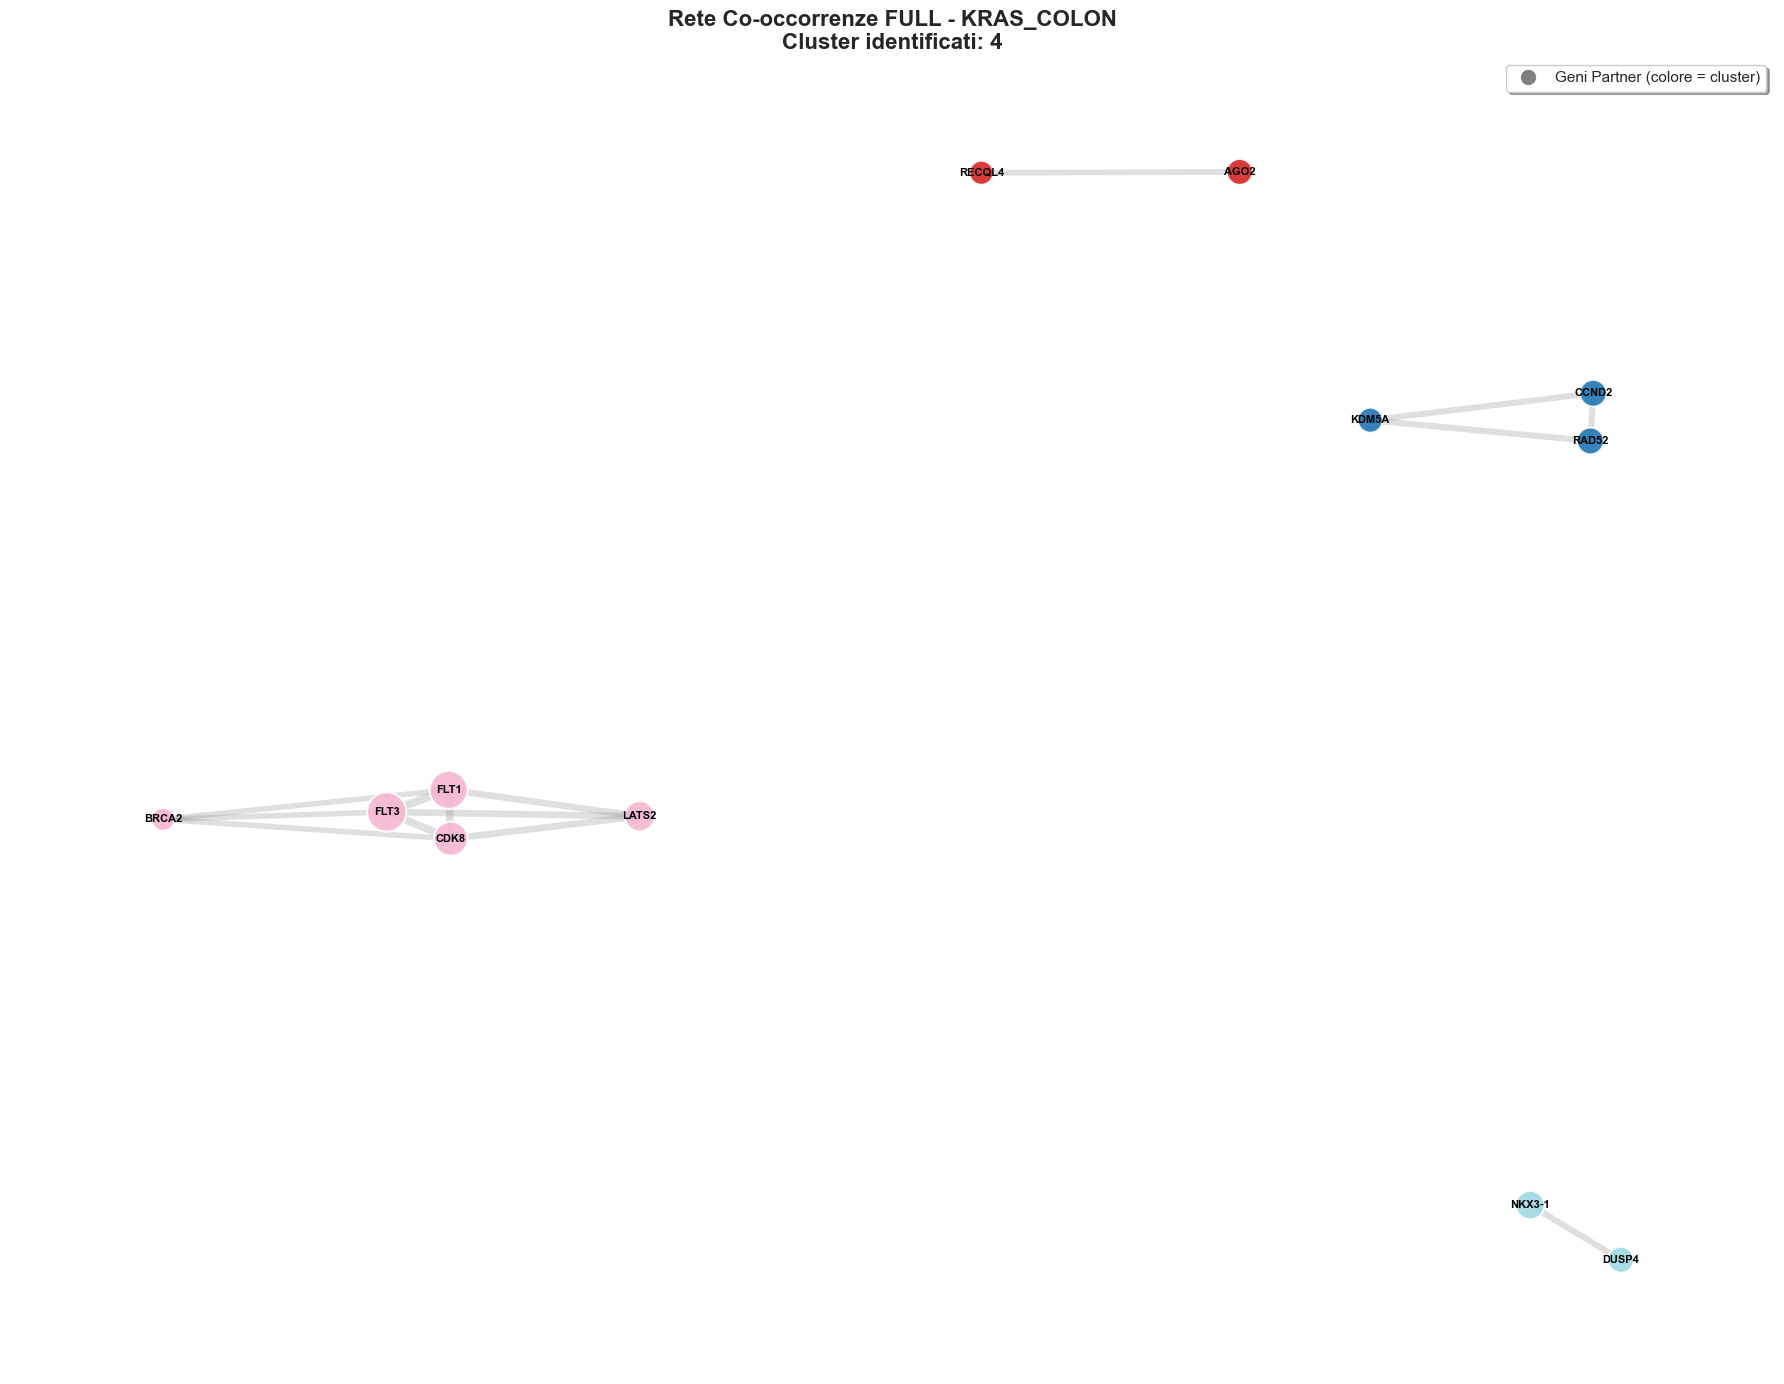

✅ Rete FULL per KRAS_COLON salvata. Nodi: 12, Archi: 14
[!] KRAS non presente nella rete (non supera i filtri).

--- 🌐 GENERAZIONE RETI 2D: PANCREAS ---


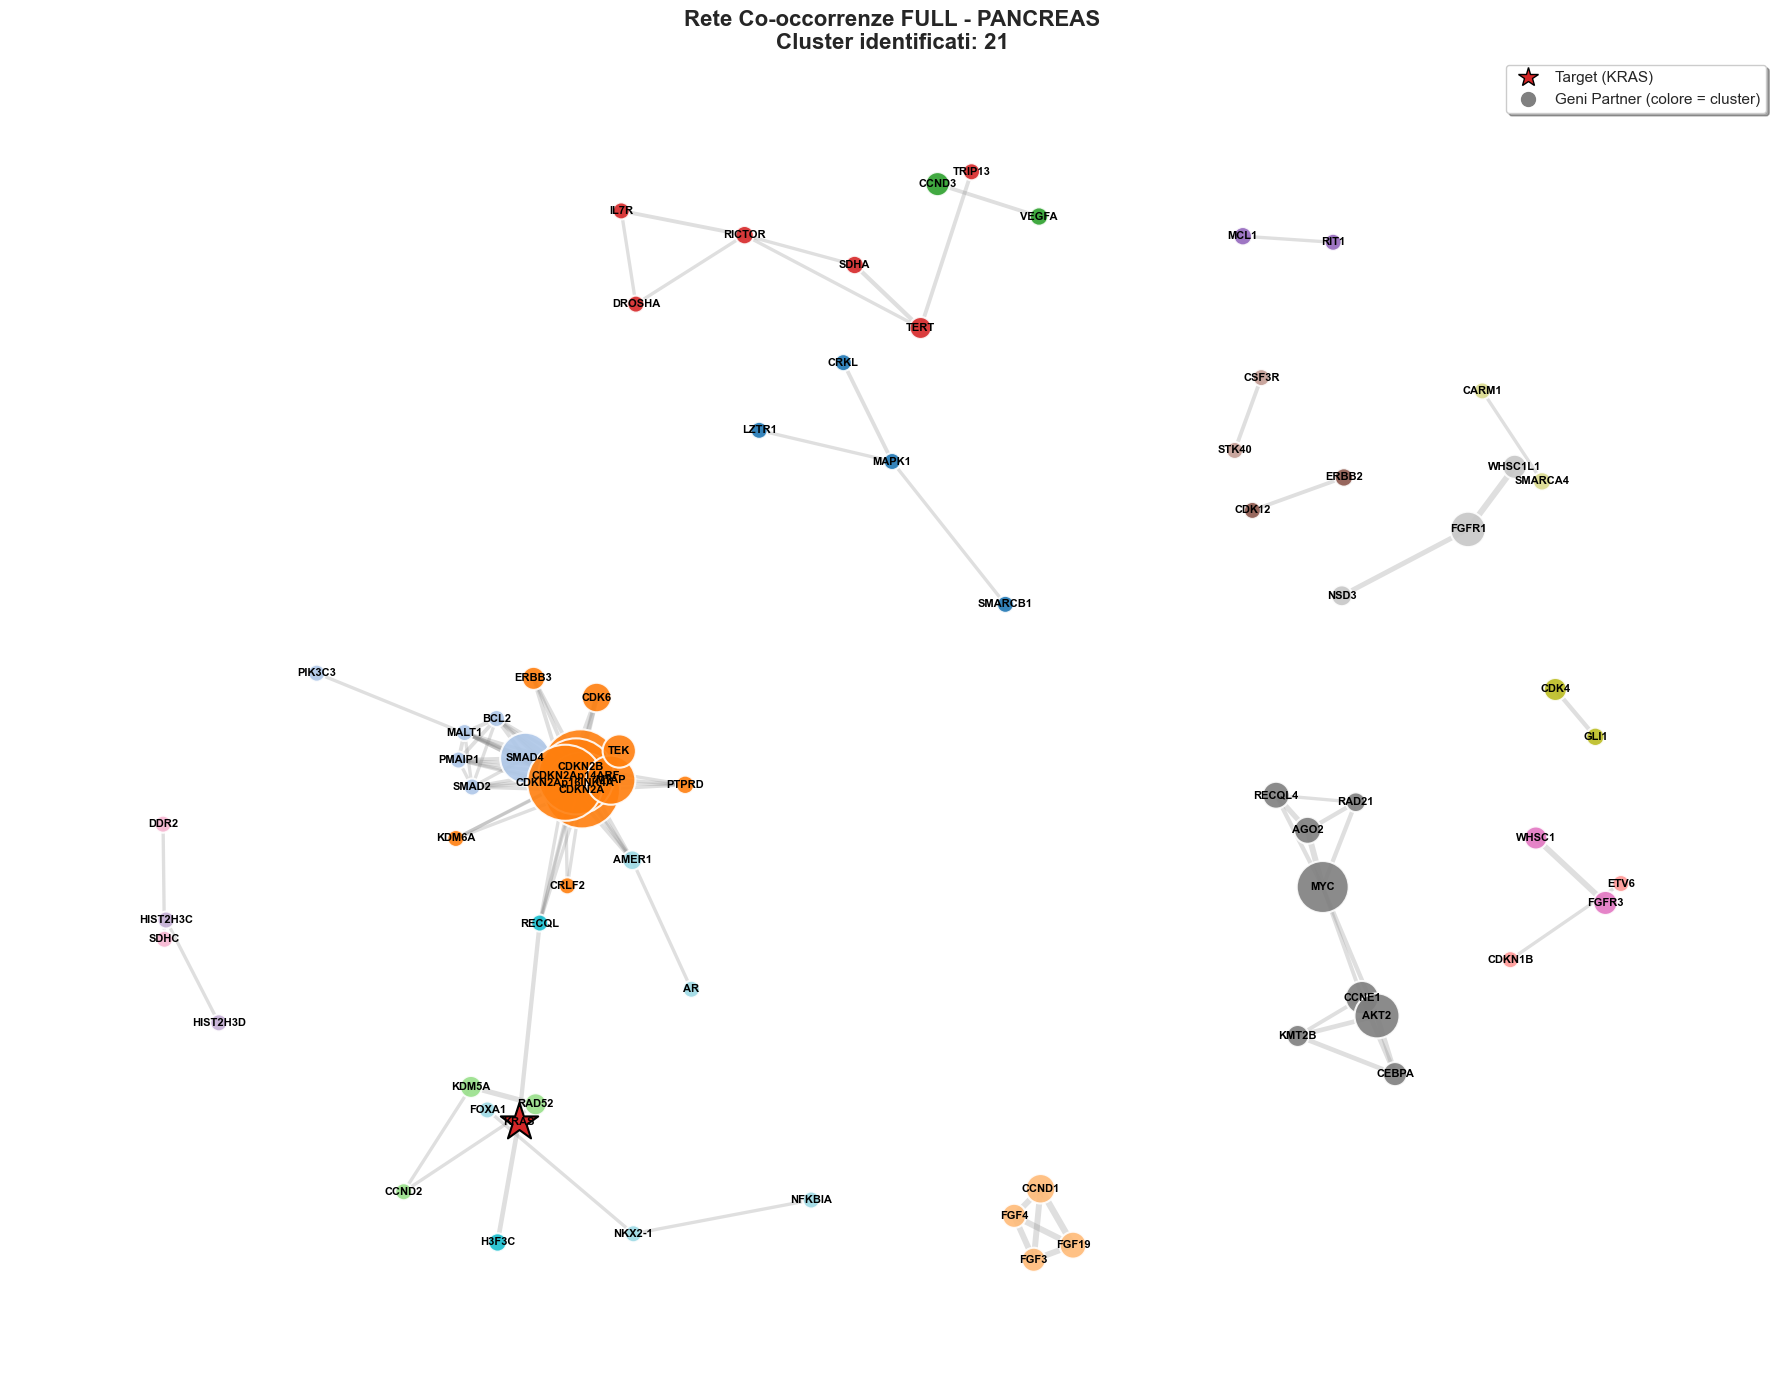

✅ Rete FULL per PANCREAS salvata. Nodi: 73, Archi: 120


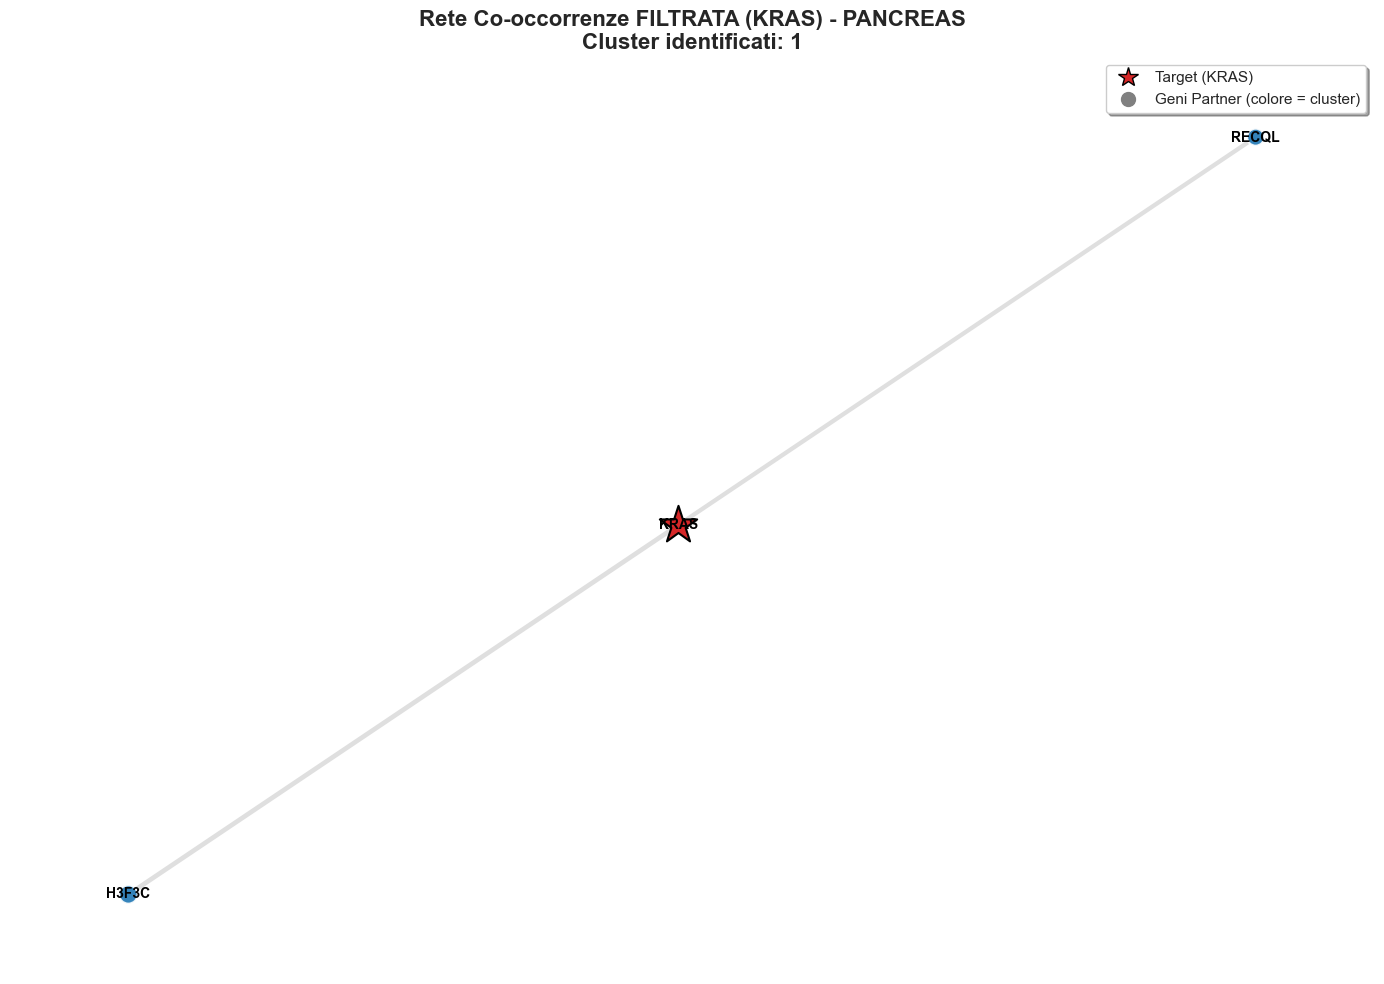

✅ Rete FILTRATA (KRAS) per PANCREAS salvata. Nodi: 3, Archi: 2

--- 🌐 GENERAZIONE RETI 2D: LUNG ---


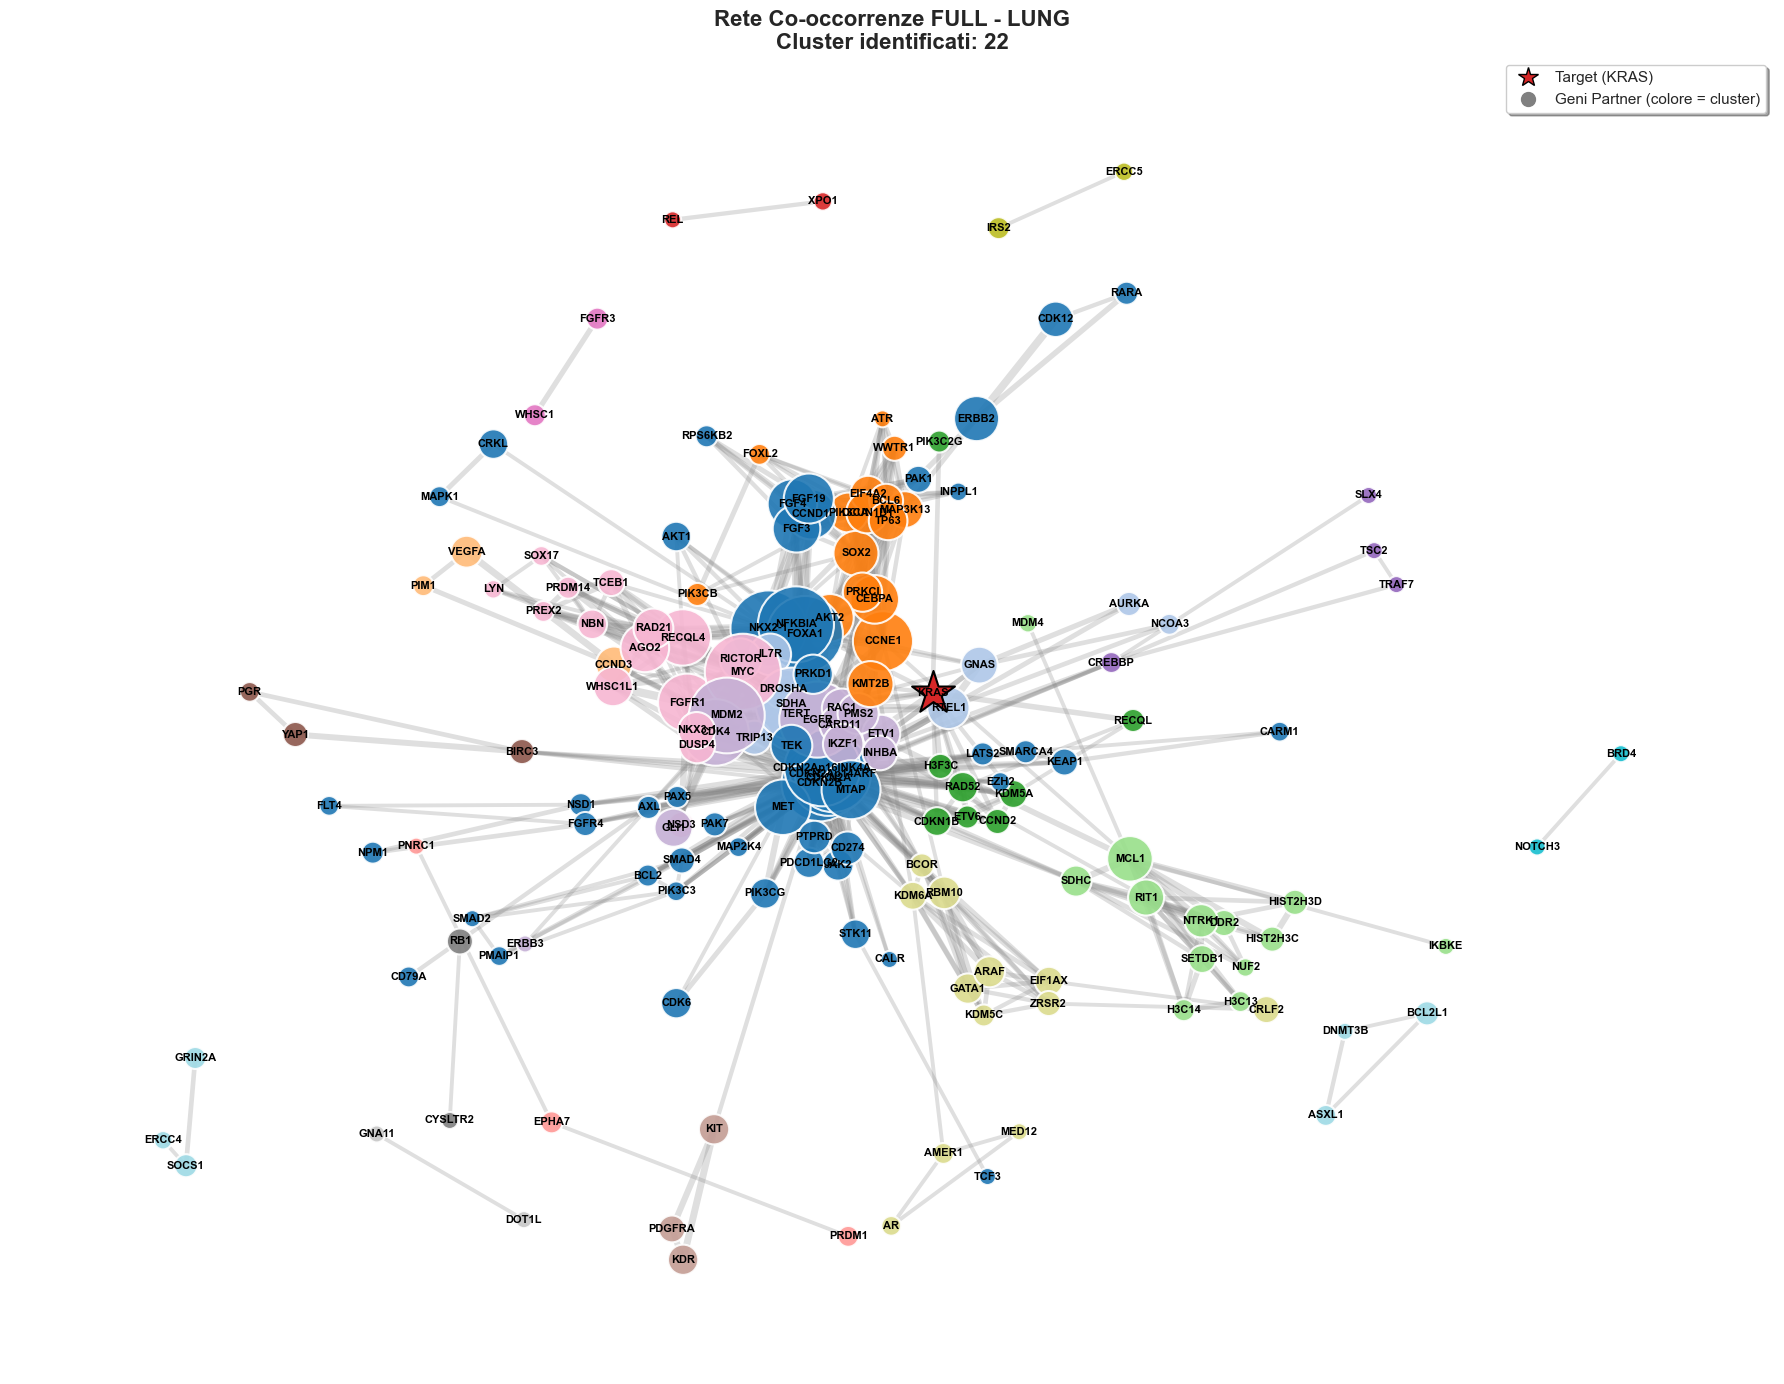

✅ Rete FULL per LUNG salvata. Nodi: 172, Archi: 743


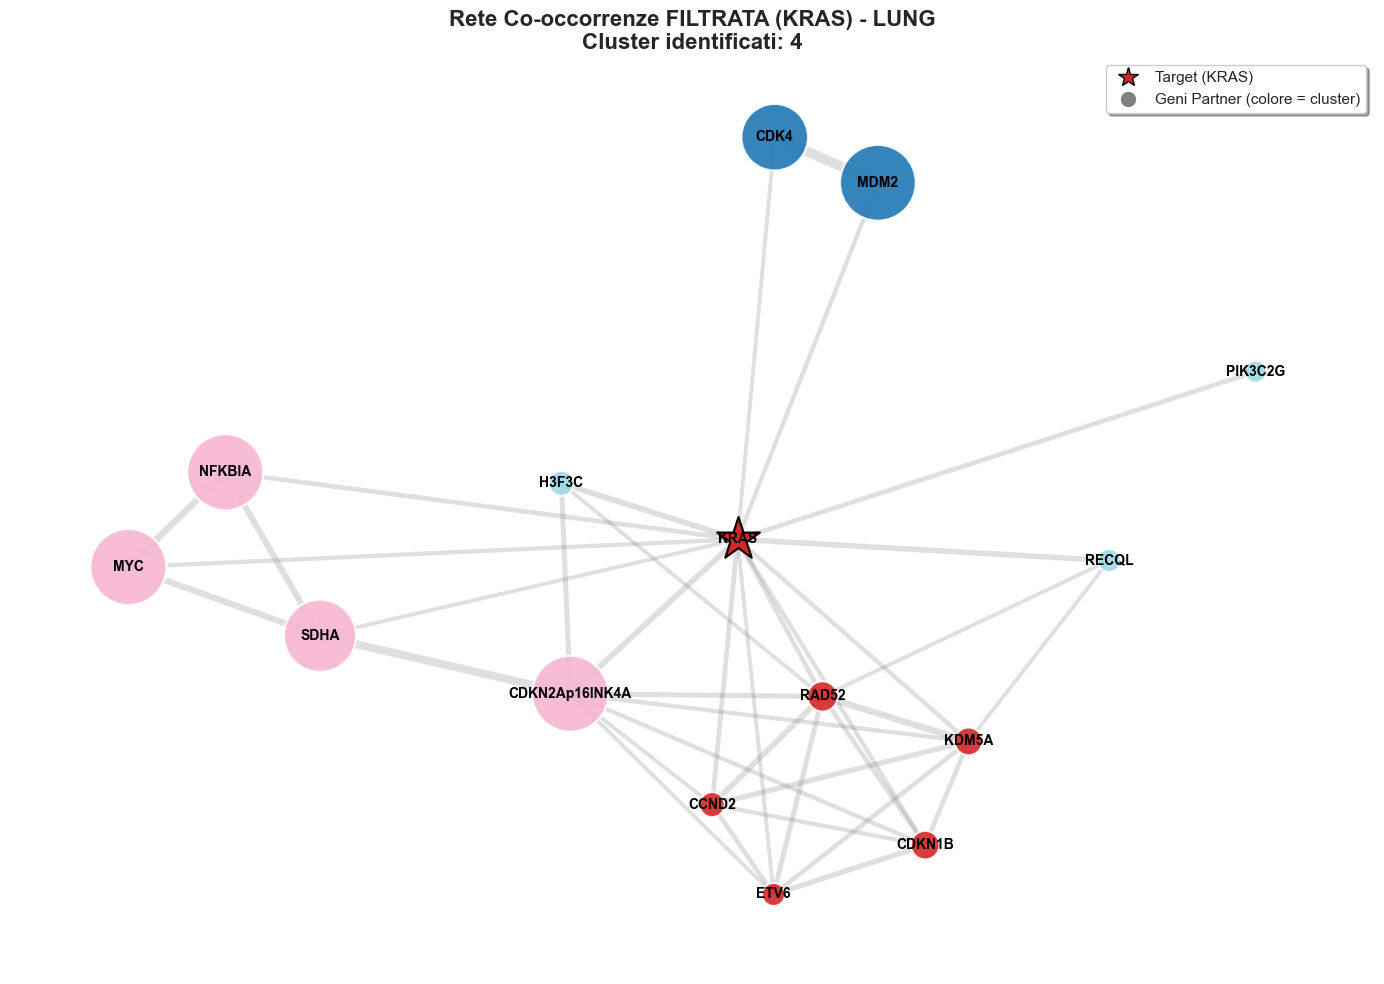

✅ Rete FILTRATA (KRAS) per LUNG salvata. Nodi: 15, Archi: 38

--- 🌐 GENERAZIONE RETI 2D: COLON ---


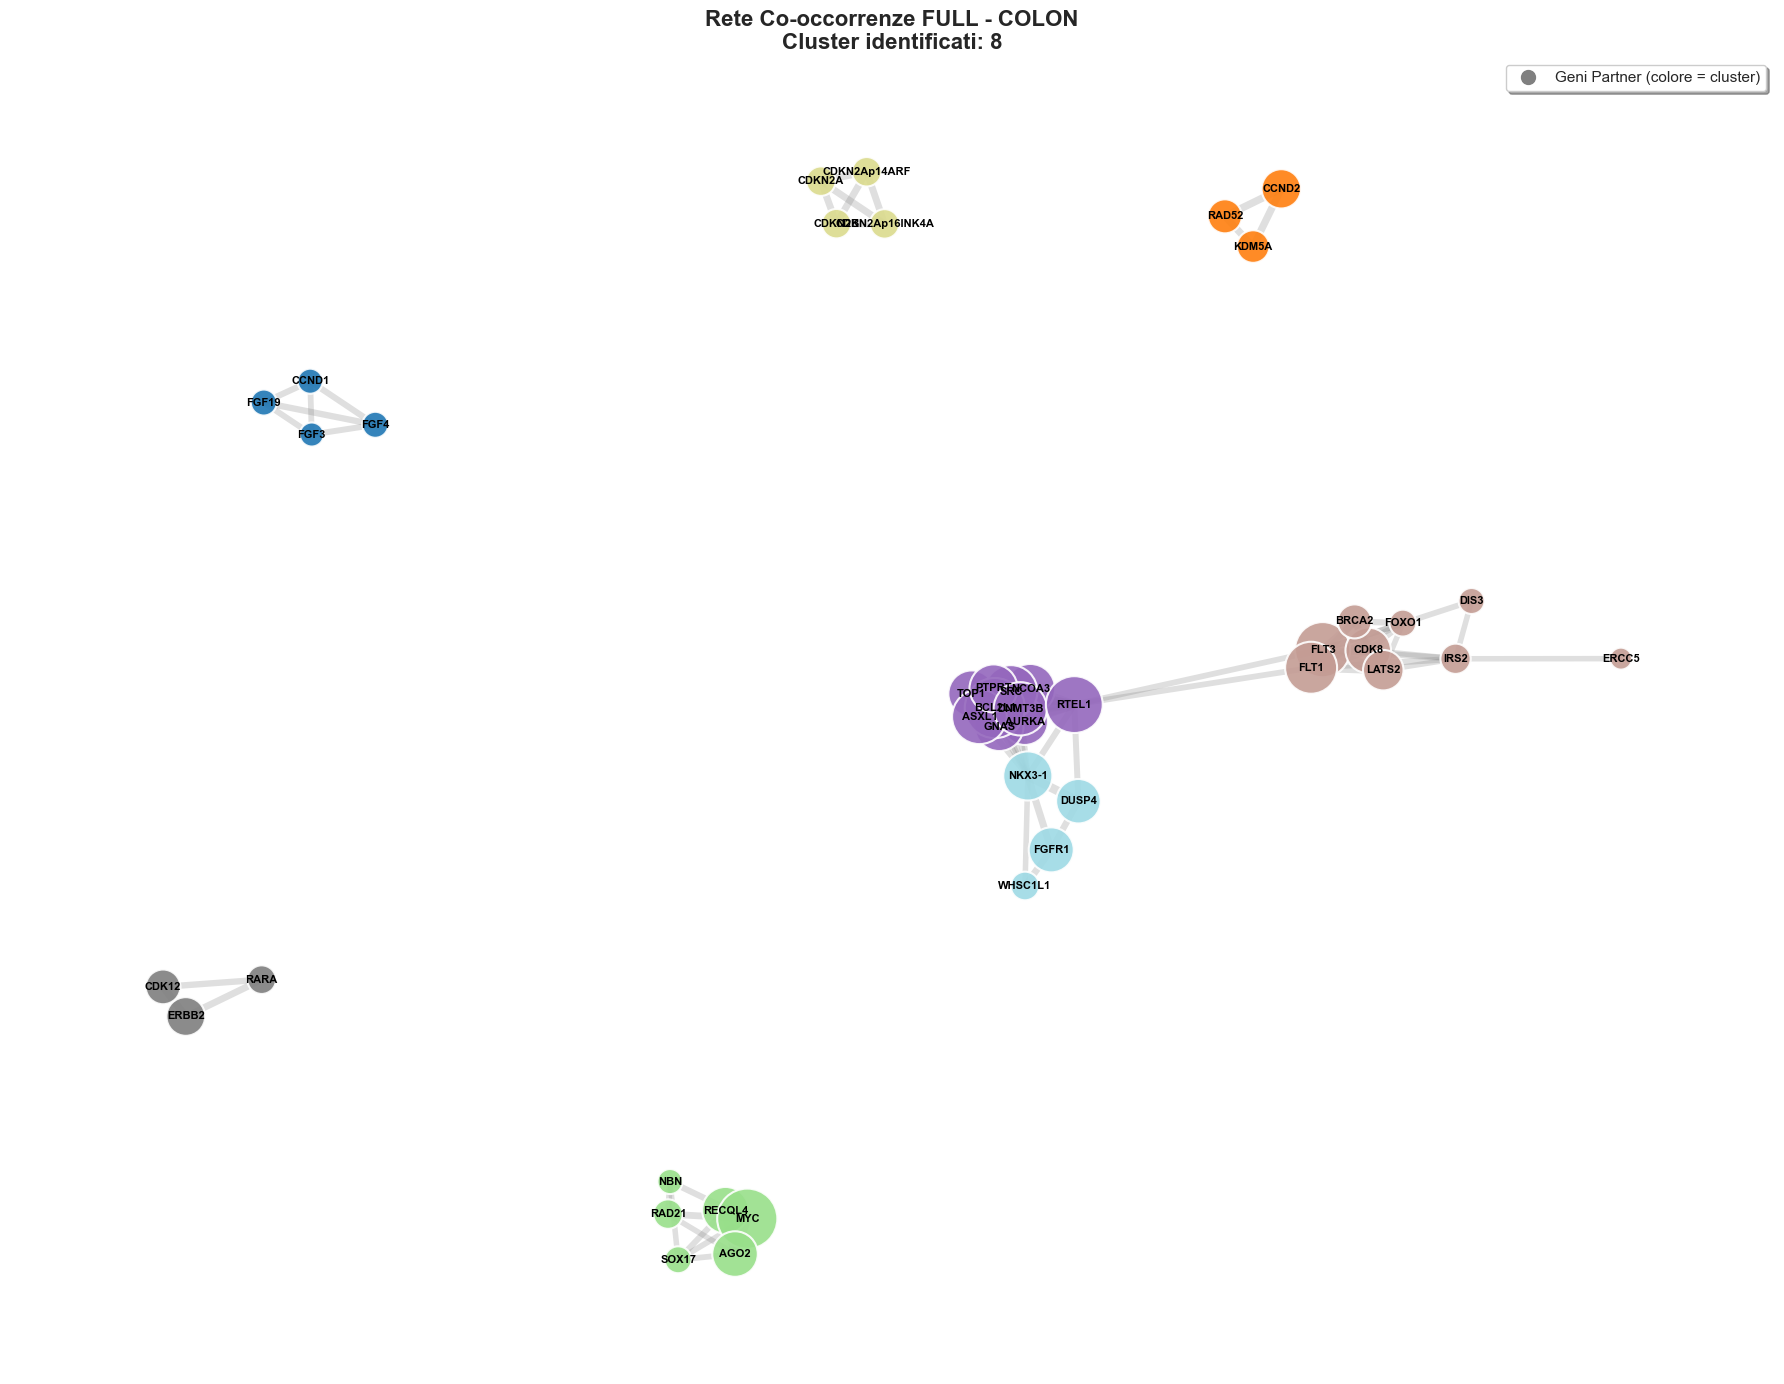

✅ Rete FULL per COLON salvata. Nodi: 43, Archi: 111
[!] KRAS non presente nella rete (non supera i filtri).


In [34]:
# ==========================================
# CELLA 6: COSTRUZIONE NETWORKS 2D STATICHE (FULL E FILTERED)
# ==========================================
import networkx as nx
import networkx.algorithms.community as nx_comm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

def draw_static_network(G, coocc_matrix, cohort_name, target_gene, is_full=False):

    
    if G.number_of_nodes() == 0:
        return

# --- 1. COMMUNITY DETECTION ---
    # Se la rete ha meno di 12 nodi, è troppo piccola per fare clustering sensato.
    # Li mettiamo tutti nello stesso "Cluster 0".
    if G.number_of_nodes() < 12:
        communities = [set(G.nodes())]
        cluster_map = {node: 0 for node in G.nodes()}
    else:
        try:
            communities = nx_comm.louvain_communities(G, weight='weight', seed=42)
        except AttributeError:
            communities = nx_comm.greedy_modularity_communities(G, weight='weight')
            
        cluster_map = {}
        for i, comm in enumerate(communities):
            for node in comm:
                cluster_map[node] = i
        
    cluster_map = {}
    for i, comm in enumerate(communities):
        for node in comm:
            cluster_map[node] = i

    # --- 2. SETUP GRAFICO ---
    plt.figure(figsize=(18, 14) if is_full else (14, 10))
    pos = nx.spring_layout(G, k=0.5 if is_full else 0.9, iterations=50, seed=42)
    
    # --- 3. SEPARAZIONE TARGET E PARTNER ---
    if target_gene in G.nodes():
        partner_nodes = [n for n in G.nodes() if n != target_gene]
        target_nodes = [target_gene]
    else:
        partner_nodes = list(G.nodes())
        target_nodes = []
        
    partner_colors = [cluster_map.get(n, 0) for n in partner_nodes]
    
    partner_sizes = []
    for n in partner_nodes:
        tot = int(coocc_matrix.loc[n, n]) if n in coocc_matrix.index else 10
        partner_sizes.append(min(max(150, tot * 25), 3000))
        
    # --- 4. DISEGNO ---
    edges = G.edges()
    weights = [max(1.0, np.log2(G[u][v]['weight']) * 1.2) for u, v in edges]
    nx.draw_networkx_edges(G, pos, alpha=0.25, width=weights, edge_color='gray')
    
    if partner_nodes:
        vmax_val = max(max(partner_colors), 1) if partner_colors else 1
        nx.draw_networkx_nodes(G, pos, nodelist=partner_nodes, 
                               node_color=partner_colors, 
                               cmap=plt.cm.tab20,       
                               vmin=0, vmax=vmax_val,   
                               node_size=partner_sizes, 
                               alpha=0.9, edgecolors='white', linewidths=1.5)
                               
    if target_nodes:
        target_tot = int(coocc_matrix.loc[target_gene, target_gene]) if target_gene in coocc_matrix.index else 50
        target_size = min(max(800, target_tot * 25), 4000)
        nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, 
                               node_color='#d62728', node_shape='*', node_size=target_size, 
                               edgecolors='black', linewidths=1.5)

    nx.draw_networkx_labels(G, pos, font_size=8 if is_full else 10, font_weight='bold', font_color='black')
    
    # --- 5. TITOLI E LEGENDA ---
    net_type = "FULL" if is_full else f"FILTRATA ({target_gene})"
    plt.title(f"Rete Co-occorrenze {net_type} - {cohort_name.upper()}\nCluster identificati: {len(communities)}", fontsize=16, fontweight='bold')
    
    if target_nodes:
        plt.plot([], [], '*', color='#d62728', markersize=15, label=f'Target ({target_gene})', markeredgecolor='black')
    plt.plot([], [], 'o', color='gray', markersize=10, label='Geni Partner (colore = cluster)')
    plt.legend(loc='upper right', scatterpoints=1, frameon=True, shadow=True)
    
    plt.axis('off')
    plt.tight_layout()
    
    # --- 6. SALVATAGGIO ---
    out_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/networks"
    os.makedirs(out_dir, exist_ok=True)
    
    filename = f"Static_Full_Network_{cohort_name}.png" if is_full else f"Static_Filtered_Network_{target_gene}_{cohort_name}.png"
    img_path = f"{out_dir}/{filename}"
    plt.savefig(img_path, dpi=200)
    plt.show() 
    print(f"✅ Rete {net_type} per {cohort_name.upper()} salvata. Nodi: {G.number_of_nodes()}, Archi: {G.number_of_edges()}")


def build_all_networks(cohort_name):
    print(f"\n--- 🌐 GENERAZIONE RETI 2D: {cohort_name.upper()} ---")
    
    stats_file = f"{OUTPUT_BASE_DIR}/{cohort_name}/stats/Full_Cooccurrence_Stats_{cohort_name}.tsv"
    coocc_file = f"{OUTPUT_BASE_DIR}/{cohort_name}/matrices/M_cooccurrence_{cohort_name}.tsv"
    
    if not os.path.exists(stats_file) or not os.path.exists(coocc_file):
        print(f"[!] File mancanti per {cohort_name}.")
        return
        
    df_stats = pd.read_csv(stats_file, sep='\t')
    coocc_matrix = pd.read_csv(coocc_file, sep='\t', index_col=0)
    
    p_thresh = COOCC_PARAMS[cohort_name]['p_val']
    log_thresh = COOCC_PARAMS[cohort_name]['log2or']
    min_cooc = COOCC_PARAMS[cohort_name]['min_cooc']
    
    valid_edges = df_stats[(df_stats['P_Value'] <= p_thresh) & 
                           (df_stats['Log2OR'] >= log_thresh) & 
                           (df_stats['Co_Occurrence_Count'] >= min_cooc)]
                           
    G_full = nx.Graph()
    for _, row in valid_edges.iterrows():
        G_full.add_edge(row['Gene_A'], row['Gene_B'], weight=int(row['Co_Occurrence_Count']))

    if G_full.number_of_nodes() == 0:
        print(f"[-] Nessuna rete formata per {cohort_name}.")
        return

    # 1. Plot FULL
    draw_static_network(G_full, coocc_matrix, cohort_name, TARGET_GENE, is_full=True)
    
    # 2. Plot FILTRATA
    if TARGET_GENE in G_full.nodes():
        neighbors = list(G_full.neighbors(TARGET_GENE))
        G_filtered = G_full.subgraph(neighbors + [TARGET_GENE]).copy()
        draw_static_network(G_filtered, coocc_matrix, cohort_name, TARGET_GENE, is_full=False)
    else:
        print(f"[!] {TARGET_GENE} non presente nella rete (non supera i filtri).")

for name in COORTI.keys():
    build_all_networks(name)

## METRICHE RETE FILTRATA


In [35]:
# ==========================================
# CELLA 7: METRICHE TOPOLOGICHE
# ==========================================

def calculate_metrics(cohort_name):
    print(f"\n--- 📊 ESTRAZIONE METRICHE: {cohort_name.upper()} ---")
    
    stats_file = f"{OUTPUT_BASE_DIR}/{cohort_name}/stats/Full_Cooccurrence_Stats_{cohort_name}.tsv"
    out_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/stats"
    os.makedirs(out_dir, exist_ok=True)
    
    if not os.path.exists(stats_file):
        print(f"[!] File stats mancante per {cohort_name}.")
        return
        
    df_stats = pd.read_csv(stats_file, sep='\t')
    
    # Parametri globali
    p_thresh = COOCC_PARAMS[cohort_name]['p_val']
    log_thresh = COOCC_PARAMS[cohort_name]['log2or']
    min_cooc = COOCC_PARAMS[cohort_name]['min_cooc']
    
    # Ricostruiamo la rete filtrata in memoria
    valid_edges = df_stats[(df_stats['P_Value'] <= p_thresh) & 
                           (df_stats['Log2OR'] >= log_thresh) & 
                           (df_stats['Co_Occurrence_Count'] >= min_cooc)]
                           
    G_full = nx.Graph()
    for _, row in valid_edges.iterrows():
        G_full.add_edge(row['Gene_A'], row['Gene_B'], weight=int(row['Co_Occurrence_Count']))

    if TARGET_GENE not in G_full.nodes():
        print(f"[-] {TARGET_GENE} non presente, calcolo metriche annullato.")
        return
        
    neighbors = list(G_full.neighbors(TARGET_GENE))
    G = G_full.subgraph(neighbors + [TARGET_GENE]).copy()
    
    if G.number_of_nodes() == 0:
        return
        
    # Calcolo metriche
    degree_cent = nx.degree_centrality(G)
    betweenness_cent = nx.betweenness_centrality(G)
    closeness_cent = nx.closeness_centrality(G)
    clustering_coeffs = nx.clustering(G)
    
    metrics_data = []
    for node in G.nodes():
        metrics_data.append({
            'Gene': node,
            'Degree': G.degree(node),
            'Degree_Centrality': round(degree_cent.get(node, 0), 4),
            'Betweenness_Centrality': round(betweenness_cent.get(node, 0), 4),
            'Closeness_Centrality': round(closeness_cent.get(node, 0), 4),
            'Clustering_Coefficient': round(clustering_coeffs.get(node, 0), 4)
        })
        
    metrics_df = pd.DataFrame(metrics_data).sort_values(by='Degree_Centrality', ascending=False)
    metrics_df.to_csv(f"{out_dir}/Network_Metrics_Filtered_{cohort_name}.tsv", sep='\t', index=False)
    
    print(f"✅ Metriche salvate. Top 3 Hub identificati:")
    print(metrics_df[['Gene', 'Degree', 'Betweenness_Centrality']].head(3).to_string(index=False))

for name in COORTI.keys():
    calculate_metrics(name)


--- 📊 ESTRAZIONE METRICHE: KRAS_PANCREAS ---
✅ Metriche salvate. Top 3 Hub identificati:
 Gene  Degree  Betweenness_Centrality
 KRAS       2                     1.0
RECQL       1                     0.0
H3F3C       1                     0.0

--- 📊 ESTRAZIONE METRICHE: KRAS_LUNG ---
✅ Metriche salvate. Top 3 Hub identificati:
          Gene  Degree  Betweenness_Centrality
          KRAS       6                  0.3778
CDKN2Ap16INK4A       5                  0.0444
        CDKN2A       5                  0.0444

--- 📊 ESTRAZIONE METRICHE: KRAS_COLON ---
[-] KRAS non presente, calcolo metriche annullato.

--- 📊 ESTRAZIONE METRICHE: PANCREAS ---
✅ Metriche salvate. Top 3 Hub identificati:
 Gene  Degree  Betweenness_Centrality
 KRAS       2                     1.0
RECQL       1                     0.0
H3F3C       1                     0.0

--- 📊 ESTRAZIONE METRICHE: LUNG ---
✅ Metriche salvate. Top 3 Hub identificati:
          Gene  Degree  Betweenness_Centrality
          KRAS      14   